<a href="https://colab.research.google.com/github/objectrom/Flight-LTO-Emission/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

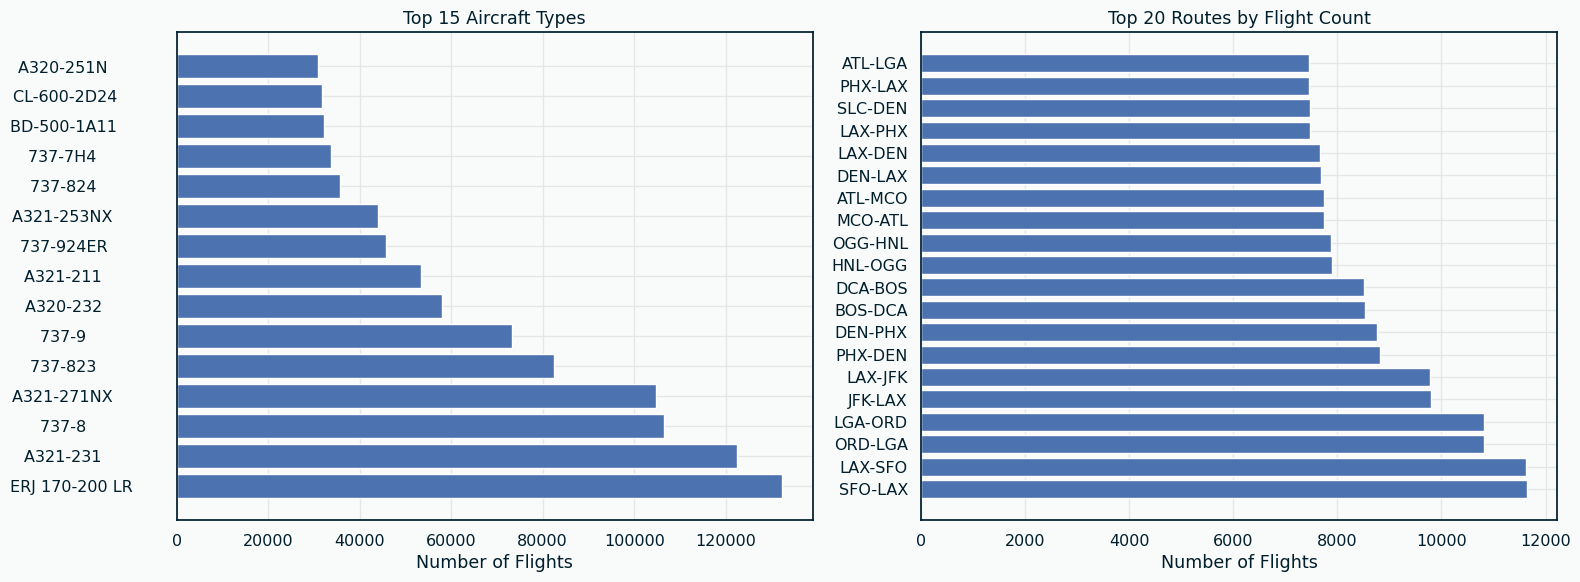

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet('/content/40_2025_final.parquet')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Aircraft type distribution
acft_counts = df['ACFT MODEL'].value_counts().head(15)
axes[0].barh(acft_counts.index, acft_counts.values)
axes[0].set_title('Top 15 Aircraft Types')
axes[0].set_xlabel('Number of Flights')

# 2. Route distribution
df['ROUTE'] = df['ORIGIN'] + '-' + df['DEST']
route_counts = df['ROUTE'].value_counts().head(20)
axes[1].barh(route_counts.index, route_counts.values)
axes[1].set_title('Top 20 Routes by Flight Count')
axes[1].set_xlabel('Number of Flights')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_00_aircraft_routes.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
df.shape

(1532364, 84)

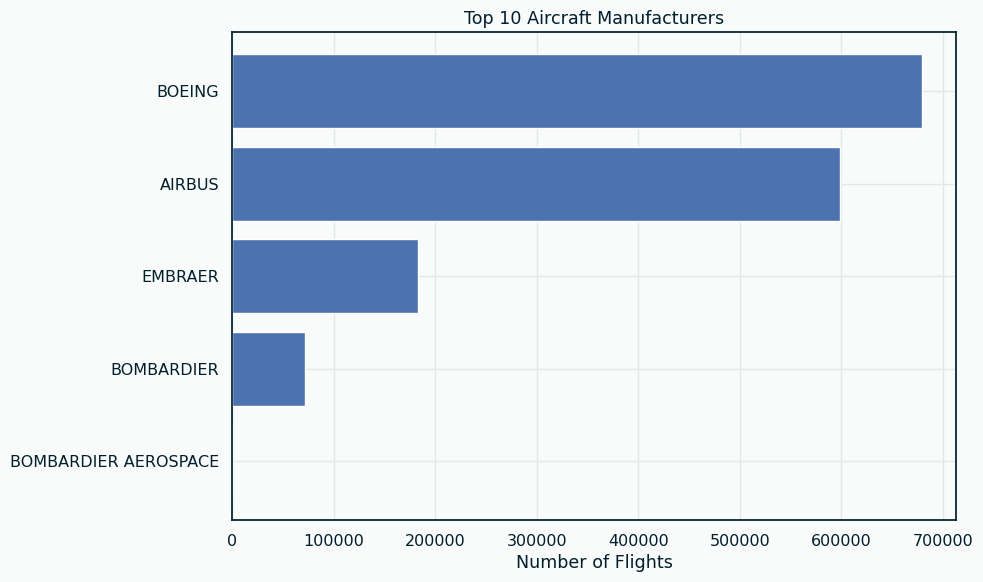

<Figure size 640x480 with 0 Axes>

In [ ]:
mfr_counts = df['ACFT MFR CLEAN'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(mfr_counts.index[::-1], mfr_counts.values[::-1])
plt.title('Top 10 Aircraft Manufacturers')
plt.xlabel('Number of Flights')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_01_Top_Aircraft_Manufacturers.png', dpi=150, bbox_inches='tight')
plt.show()

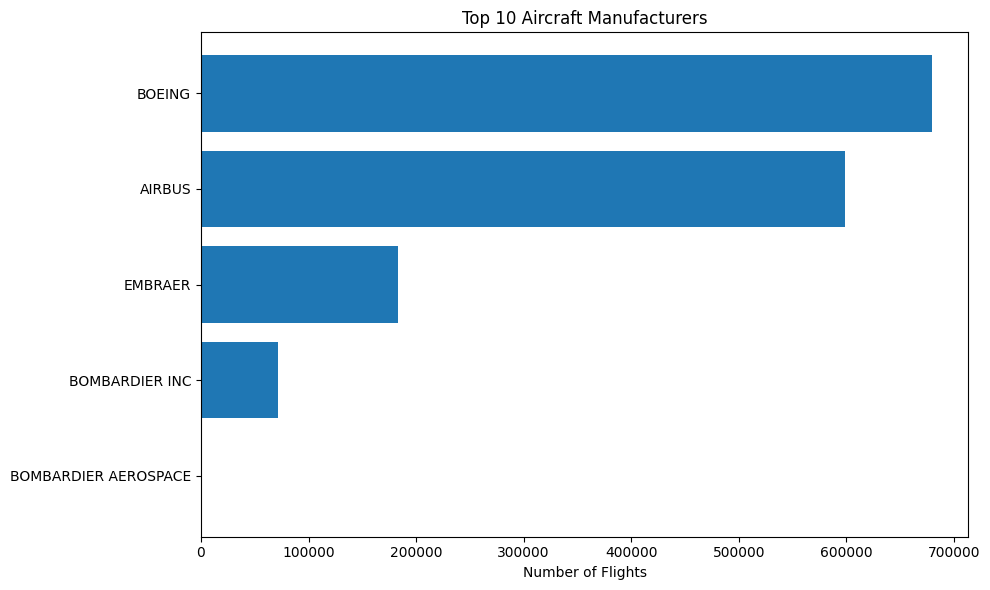

In [ ]:
mfr_map = {
    'AIRBUS INDUSTRIE': 'AIRBUS',
    'AIRBUS S A S': 'AIRBUS',
    'AIRBUS SAS': 'AIRBUS',
    'AIRBUS CANADA LP': 'AIRBUS',
    'AIRBUS CANADA LTD PTNRSP': 'AIRBUS',
    'EMBRAER S A': 'EMBRAER',
    'EMBRAER-EMPRESA BRASILEIRA DE': 'EMBRAER',
    'YABORA INDUSTRIA AERONAUTICA S': 'EMBRAER',
    'C SERIES AIRCRAFT LTD PTNRSP' : 'AIRBUS',
    'EMPRESA BRASILEIRA DE AERO S A' : 'EMBRAER'
}

df['ACFT MFR CLEAN'] = df['ACFT MFR'].replace(mfr_map)

mfr_counts = df['ACFT MFR CLEAN'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(mfr_counts.index[::-1], mfr_counts.values[::-1])
plt.title('Top 10 Aircraft Manufacturers')
plt.xlabel('Number of Flights')
plt.tight_layout()
plt.show()

In [ ]:
print(df['DISTANCE'].describe())
print(df['DISTANCE'].value_counts().head(10))

count    1.532364e+06
mean     1.113521e+03
std      7.723444e+02
min      8.400000e+01
25%      5.470000e+02
50%      8.680000e+02
75%      1.598000e+03
max      5.095000e+03
Name: DISTANCE, dtype: float64
DISTANCE
337.0     27590
733.0     21638
862.0     20346
2475.0    19569
602.0     17586
399.0     17037
599.0     17020
937.0     15648
404.0     15477
370.0     14942
Name: count, dtype: int64


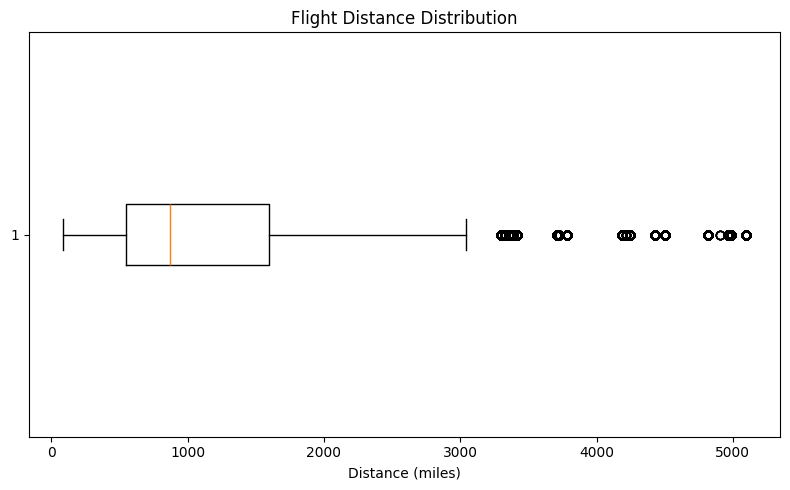

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['DISTANCE'].dropna(), vert=False)
plt.title('Flight Distance Distribution')
plt.xlabel('Distance (miles)')
plt.tight_layout()
plt.show()


In [ ]:
# Classify geographic route type

print(df.groupby('GEO_TYPE')['DISTANCE'].describe())

                      count         mean          std     min     25%     50%  \
GEO_TYPE                                                                        
Alaska Route        28611.0  1582.588655   682.162585   571.0  1448.0  1448.0   
Domestic          1270232.0   892.528334   522.456249    89.0   529.0   760.0   
Hawaii Route        88682.0  1935.158014  1352.641767    84.0   163.0  2504.0   
Transcontinental   144839.0  2455.887475   133.910250  2125.0  2402.0  2465.0   

                     75%     max  
GEO_TYPE                          
Alaska Route      1542.0  3417.0  
Domestic          1199.0  2733.0  
Hawaii Route      2677.0  5095.0  
Transcontinental  2565.0  2704.0  


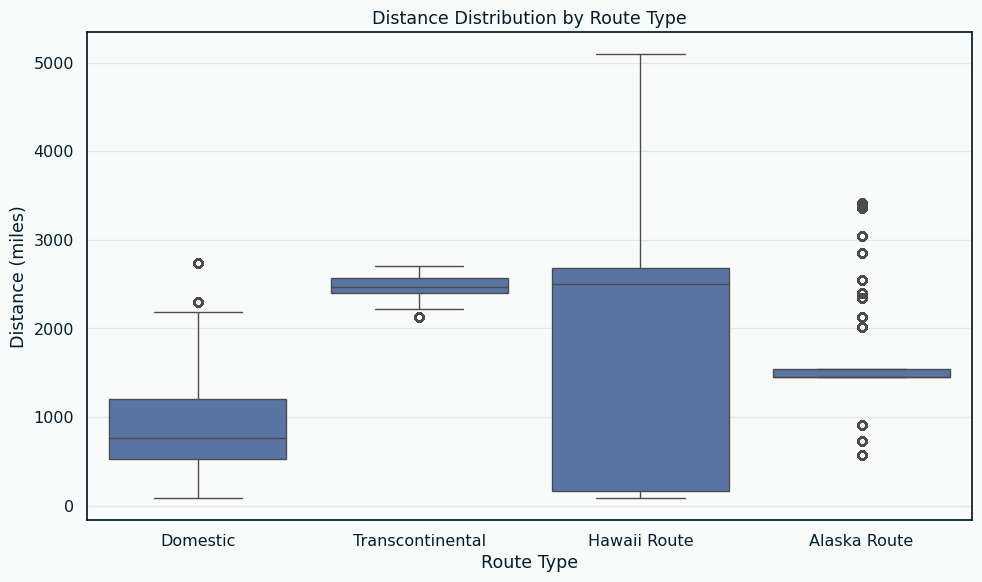

<Figure size 640x480 with 0 Axes>

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='GEO_TYPE', y='DISTANCE')
plt.title('Distance Distribution by Route Type')
plt.xlabel('Route Type')
plt.ylabel('Distance (miles)')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_05_Distance_Distribution_by_route_Type.png', dpi=150, bbox_inches='tight')
plt.show()

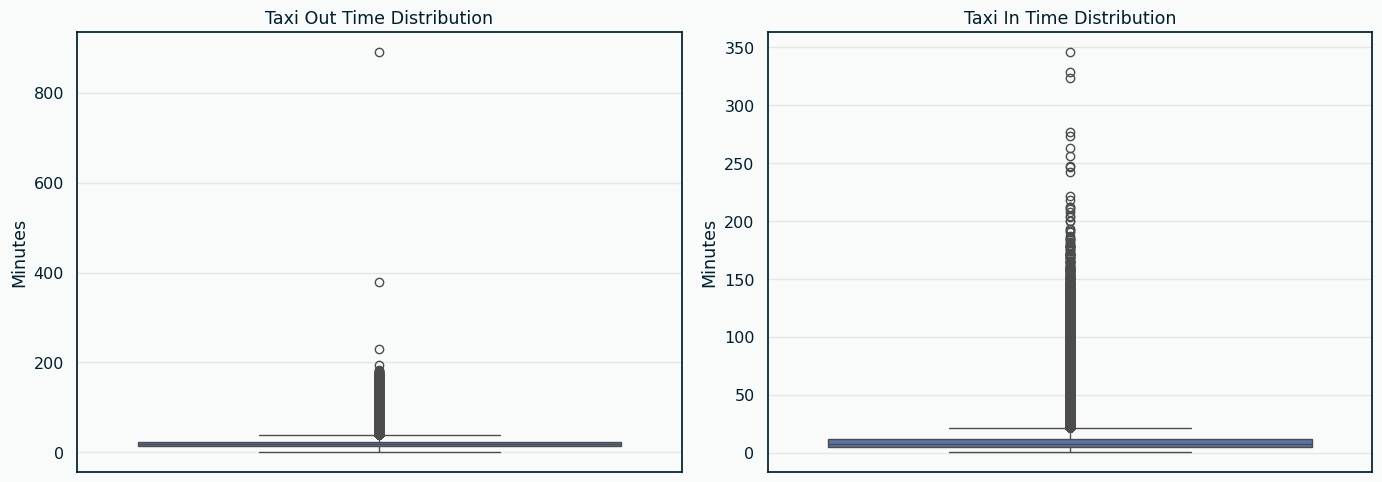

           TAXI_OUT       TAXI_IN
count  1.532364e+06  1.532031e+06
mean   2.055522e+01  9.822827e+00
std    1.144546e+01  7.856677e+00
min    1.000000e+00  1.000000e+00
25%    1.400000e+01  5.000000e+00
50%    1.800000e+01  8.000000e+00
75%    2.400000e+01  1.200000e+01
max    8.900000e+02  3.460000e+02


<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxi Out
sns.boxplot(data=df, y='TAXI_OUT', ax=axes[0])
axes[0].set_title('Taxi Out Time Distribution')
axes[0].set_ylabel('Minutes')

# Taxi In
sns.boxplot(data=df, y='TAXI_IN', ax=axes[1])
axes[1].set_title('Taxi In Time Distribution')
axes[1].set_ylabel('Minutes')

plt.tight_layout()
plt.show()

print(df[['TAXI_OUT', 'TAXI_IN']].describe())

plt.tight_layout()
plt.savefig('eda_06_Taxi_Out_vs_Taxi_In_Time_Distribution', dpi=150, bbox_inches='tight')
plt.show()

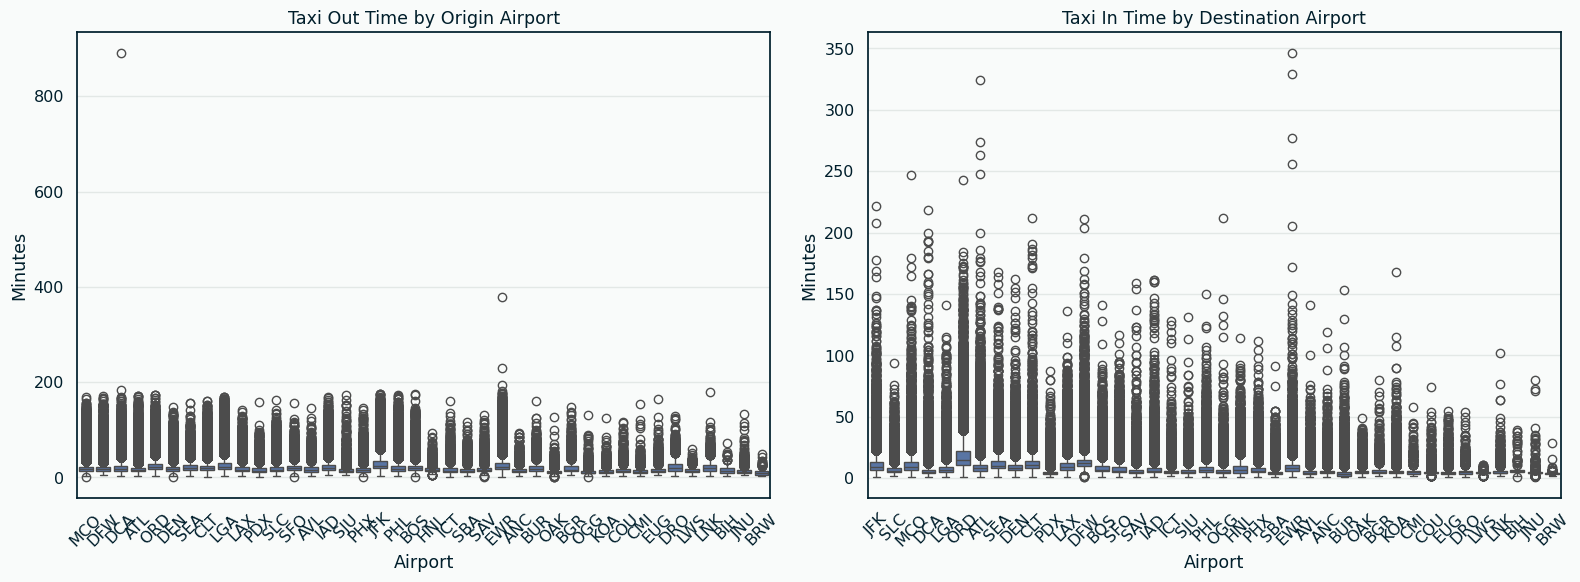

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taxi Out by Origin Airport
sns.boxplot(data=df, x='ORIGIN', y='TAXI_OUT', ax=axes[0])
axes[0].set_title('Taxi Out Time by Origin Airport')
axes[0].set_xlabel('Airport')
axes[0].set_ylabel('Minutes')
axes[0].tick_params(axis='x', rotation=45)

# Taxi In by Destination Airport
sns.boxplot(data=df, x='DEST', y='TAXI_IN', ax=axes[1])
axes[1].set_title('Taxi In Time by Destination Airport')
axes[1].set_xlabel('Airport')
axes[1].set_ylabel('Minutes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_07_Taxi_InOut_by_OD_Airport.png', dpi=150, bbox_inches='tight')
plt.show()

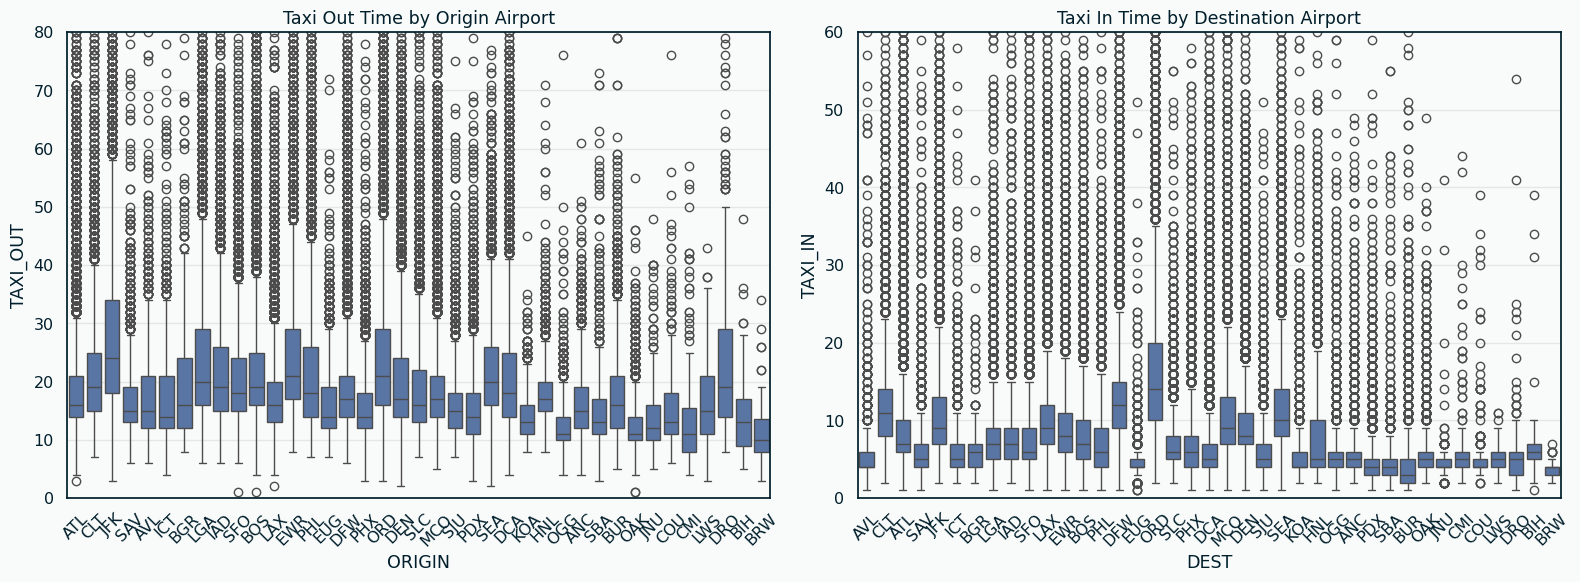

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='ORIGIN', y='TAXI_OUT', ax=axes[0])
axes[0].set_ylim(0, 80)  # cropping under outliers
axes[0].set_title('Taxi Out Time by Origin Airport')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='DEST', y='TAXI_IN', ax=axes[1])
axes[1].set_ylim(0, 60)
axes[1].set_title('Taxi In Time by Destination Airport')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print(df.columns)

Index(['YEAR', 'MONTH', 'FL_DATE', 'OP_CARRIER', 'TAIL_NUM',
       'OP_CARRIER_FL_NUM', 'ORIGIN_AIRPORT_ID', 'DEST_AIRPORT_ID',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_TIME_BLK', 'TAXI_OUT',
       'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'ARR_TIME', 'ARR_DELAY',
       'CANCELLED', 'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'TAIL_NUM_CLEAN', 'N-NUMBER', 'MFR MDL CODE', 'ENG MFR MDL', 'ENG MFR',
       'ENG MODEL', 'ACFT MFR', 'ACFT MODEL', 'Engine Identification',
       'CO EI T/O (g/kg)', 'CO EI C/O (g/kg)', 'CO EI App (g/kg)',
       'CO EI Idle (g/kg)', 'NOx EI T/O (g/kg)', 'NOx EI C/O (g/kg)',
       'NOx EI App (g/kg)', 'NOx EI Idle (g/kg)', 'Fuel Flow T/O (kg/sec)',
       'Fuel Flow C/O (kg/sec)', 'Fuel Flow App (kg/sec)',
       'Fuel Flow Idle (kg/sec)', 'ORIGIN', 'DEST', 'WHEELS_OFF_DT',
       'WHEELS_ON_DT', 'WHEELS_OFF_HOUR', 'WHEELS_ON_HOUR', 'UTC_OFFSET',
       'DEST_UTC_OFFSET', 'WHEELS_OFF_UTC', 'WHEELS_ON_UTC', 'orig_time',
       'orig_temp_C

In [ ]:
# Top 5 aircraft models per airline
top5 = df.groupby(['OP_CARRIER', 'ACFT MODEL']).size().reset_index(name='count')
top5 = top5.sort_values(['OP_CARRIER', 'count'], ascending=[True, False])
top5 = top5.groupby('OP_CARRIER').head(5)
print(top5.to_string())

    OP_CARRIER            ACFT MODEL  count
1           9E  CL-600-2D24           14149
0           9E  CL-600-2C10             137
15          AA  A321-231              95790
4           AA  737-823               82426
17          AA  A321-253NX            44029
14          AA  A321-211              17452
9           AA  A319-112              16782
23          AS  737-9                 37757
25          AS  737-990ER             24727
21          AS  737-890               23510
24          AS  737-900ER             13867
19          AS  737-790                5045
26          B6  A320-232              25148
27          B6  A321-231              22864
29          B6  BD-500-1A11           17008
30          B6  ERJ 190-100 IGW        6771
28          B6  A321-271NX             5930
31          C5  EMB-145XR               165
51          DL  A321-271NX            39254
50          DL  A321-213              29372
49          DL  A321-211              28684
33          DL  737-832         

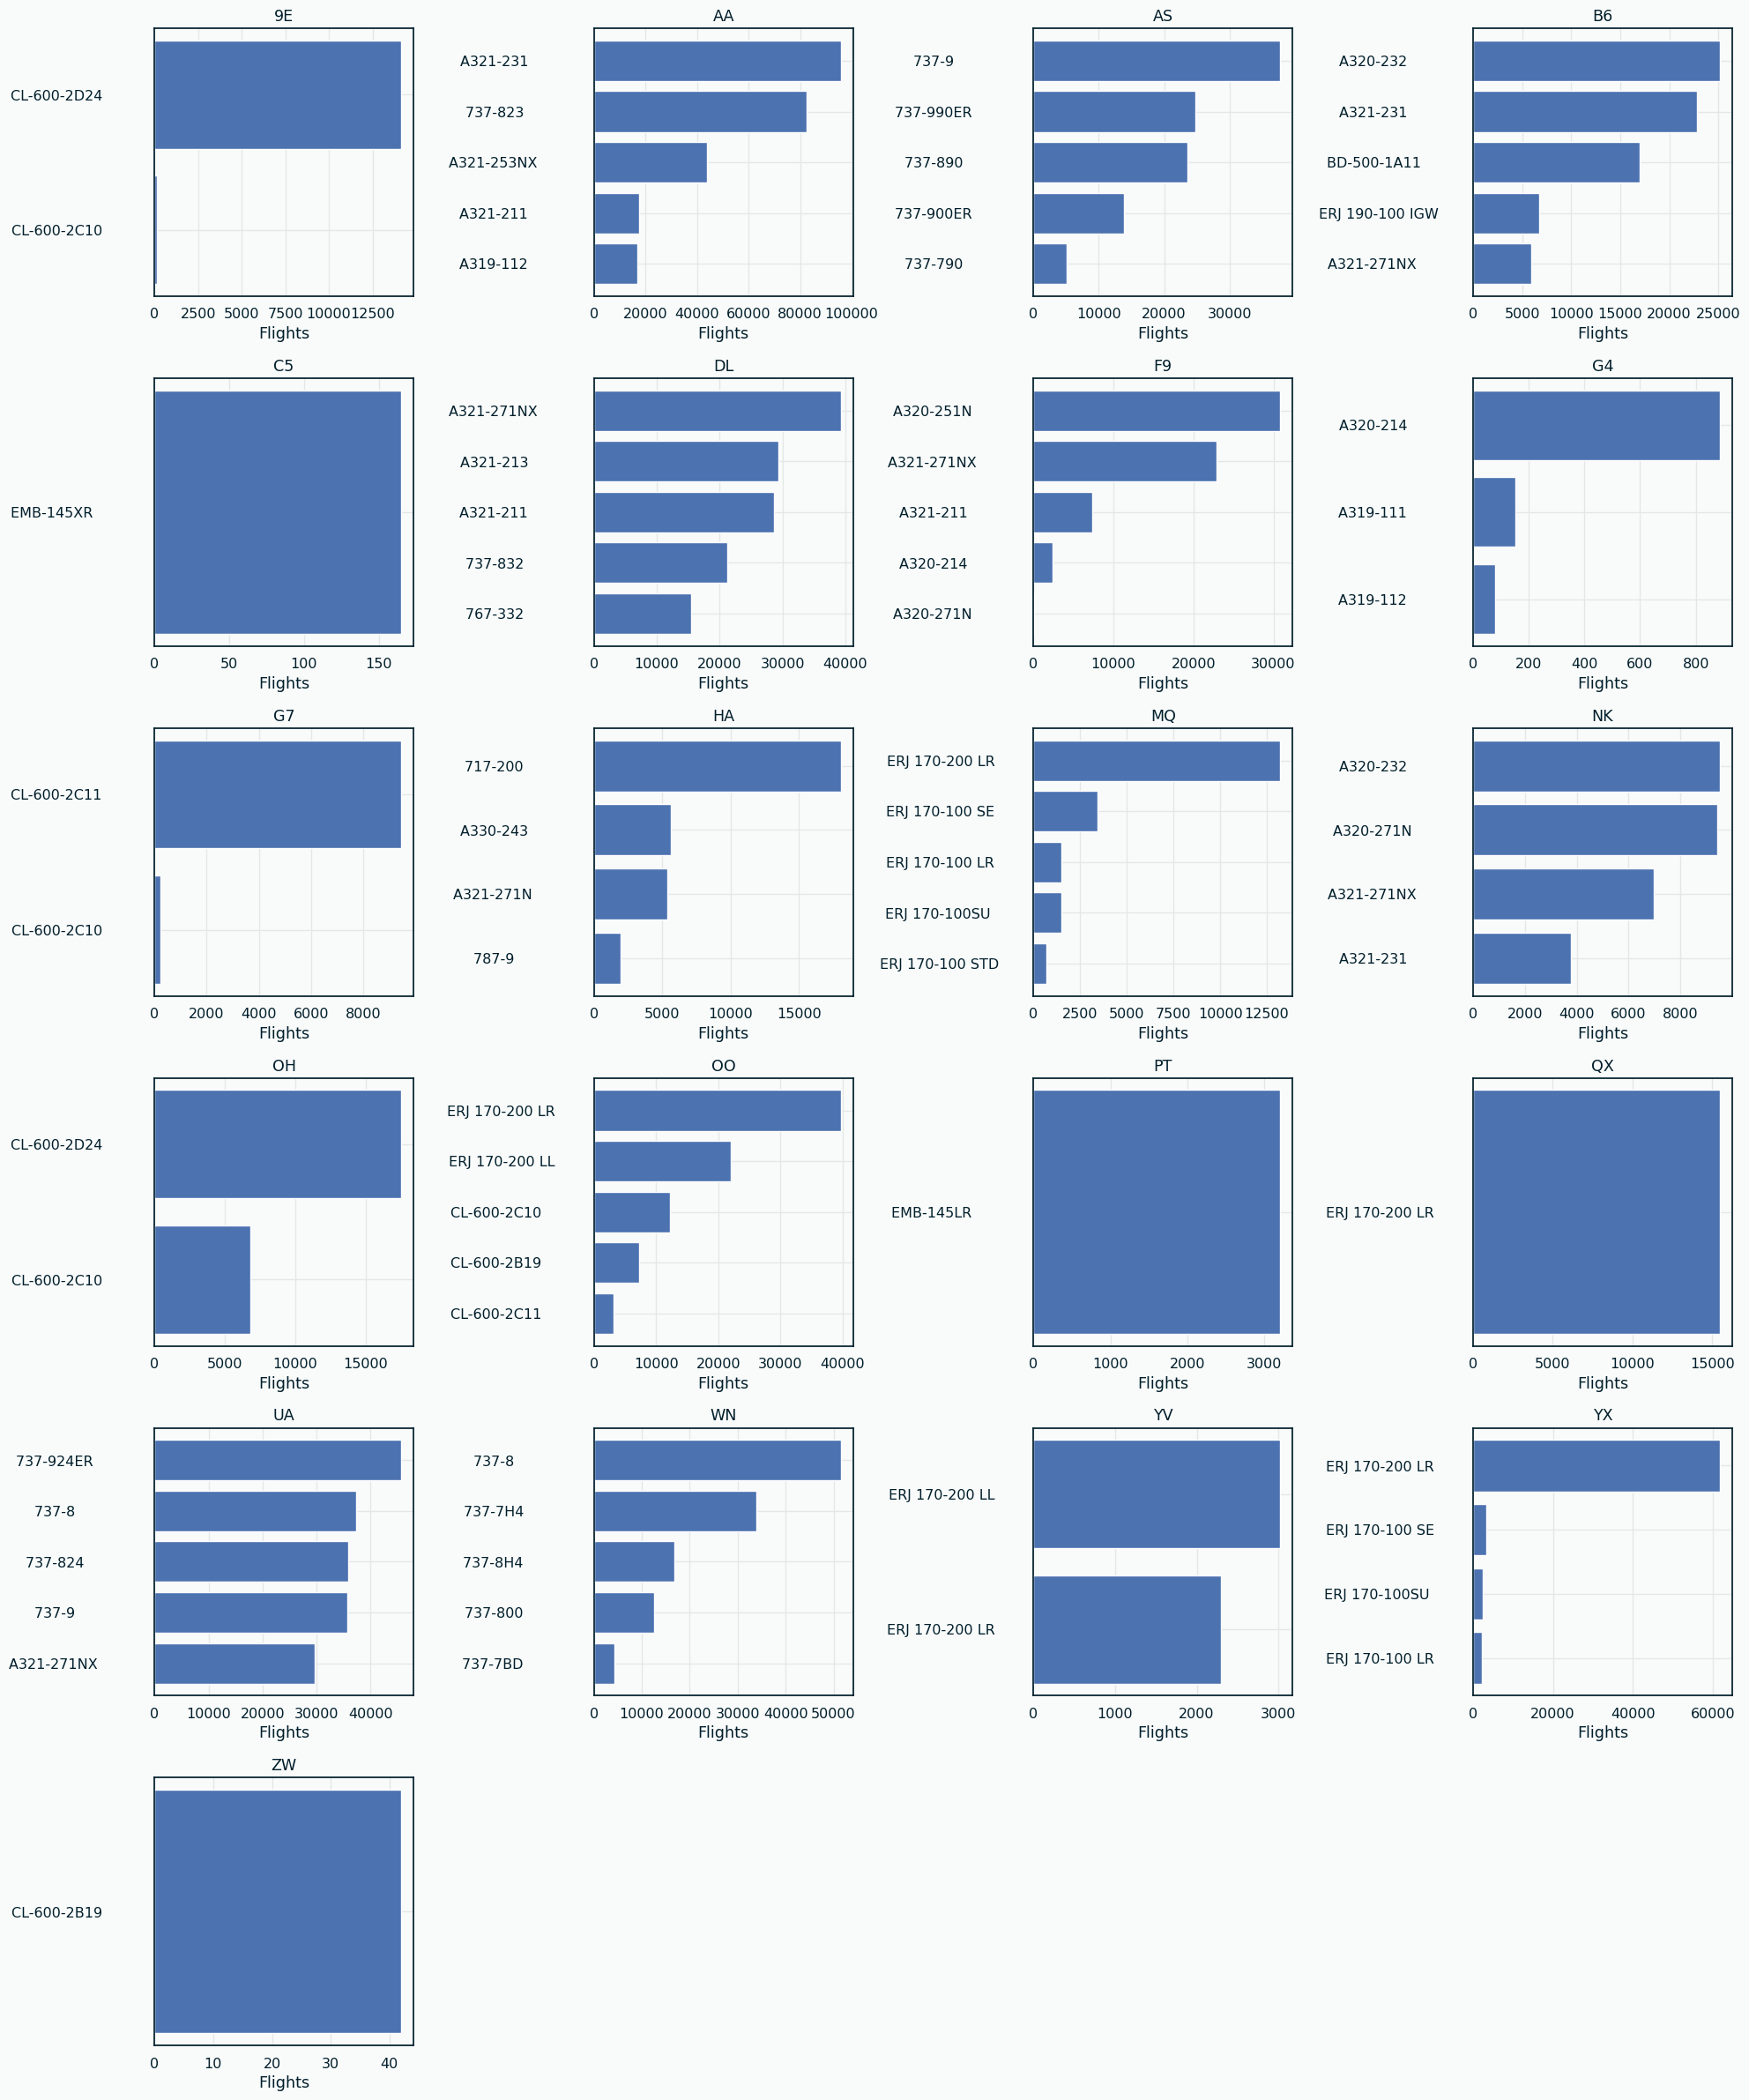

<Figure size 640x480 with 0 Axes>

In [ ]:
carriers = top5['OP_CARRIER'].unique()
n = len(carriers)
cols = 4
rows = (n + cols - 1) // cols  # 항공사 수에 맞게 자동 계산

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, carrier in enumerate(carriers):
    data = top5[top5['OP_CARRIER'] == carrier]
    axes[i].barh(data['ACFT MODEL'][::-1], data['count'][::-1])
    axes[i].set_title(f'{carrier}')
    axes[i].set_xlabel('Flights')

# 남는 빈 axes 숨기기
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_08_Aircraft_Type_by_Airline.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(df.shape)

(1532364, 84)


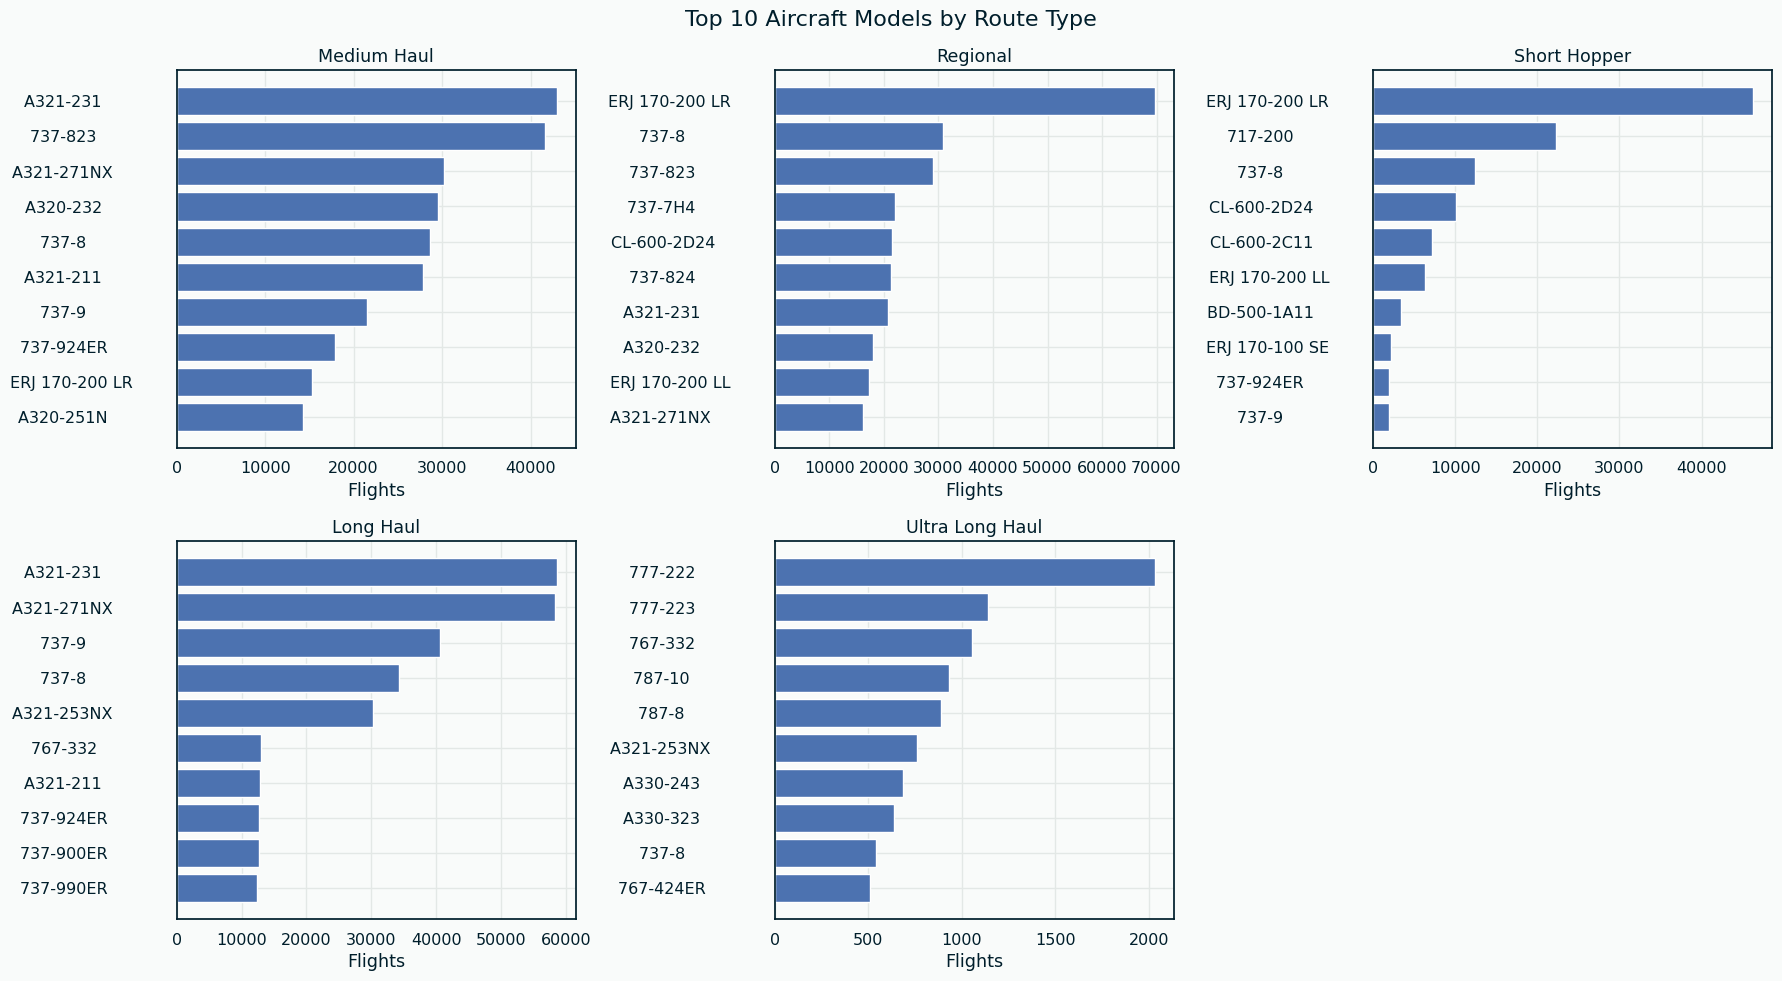

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

route_types = df['ROUTE_TYPE'].unique()

for i, route_type in enumerate(route_types):
    data = df[df['ROUTE_TYPE'] == route_type]['ACFT MODEL'].value_counts().head(10)
    axes[i].barh(data.index[::-1], data.values[::-1])
    axes[i].set_title(f'{route_type}')
    axes[i].set_xlabel('Flights')

axes[-1].set_visible(False)
plt.suptitle('Top 10 Aircraft Models by Route Type', fontsize=16)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_09_Top_Aircraft_by_Route_Type.png', dpi=150, bbox_inches='tight')
plt.show()

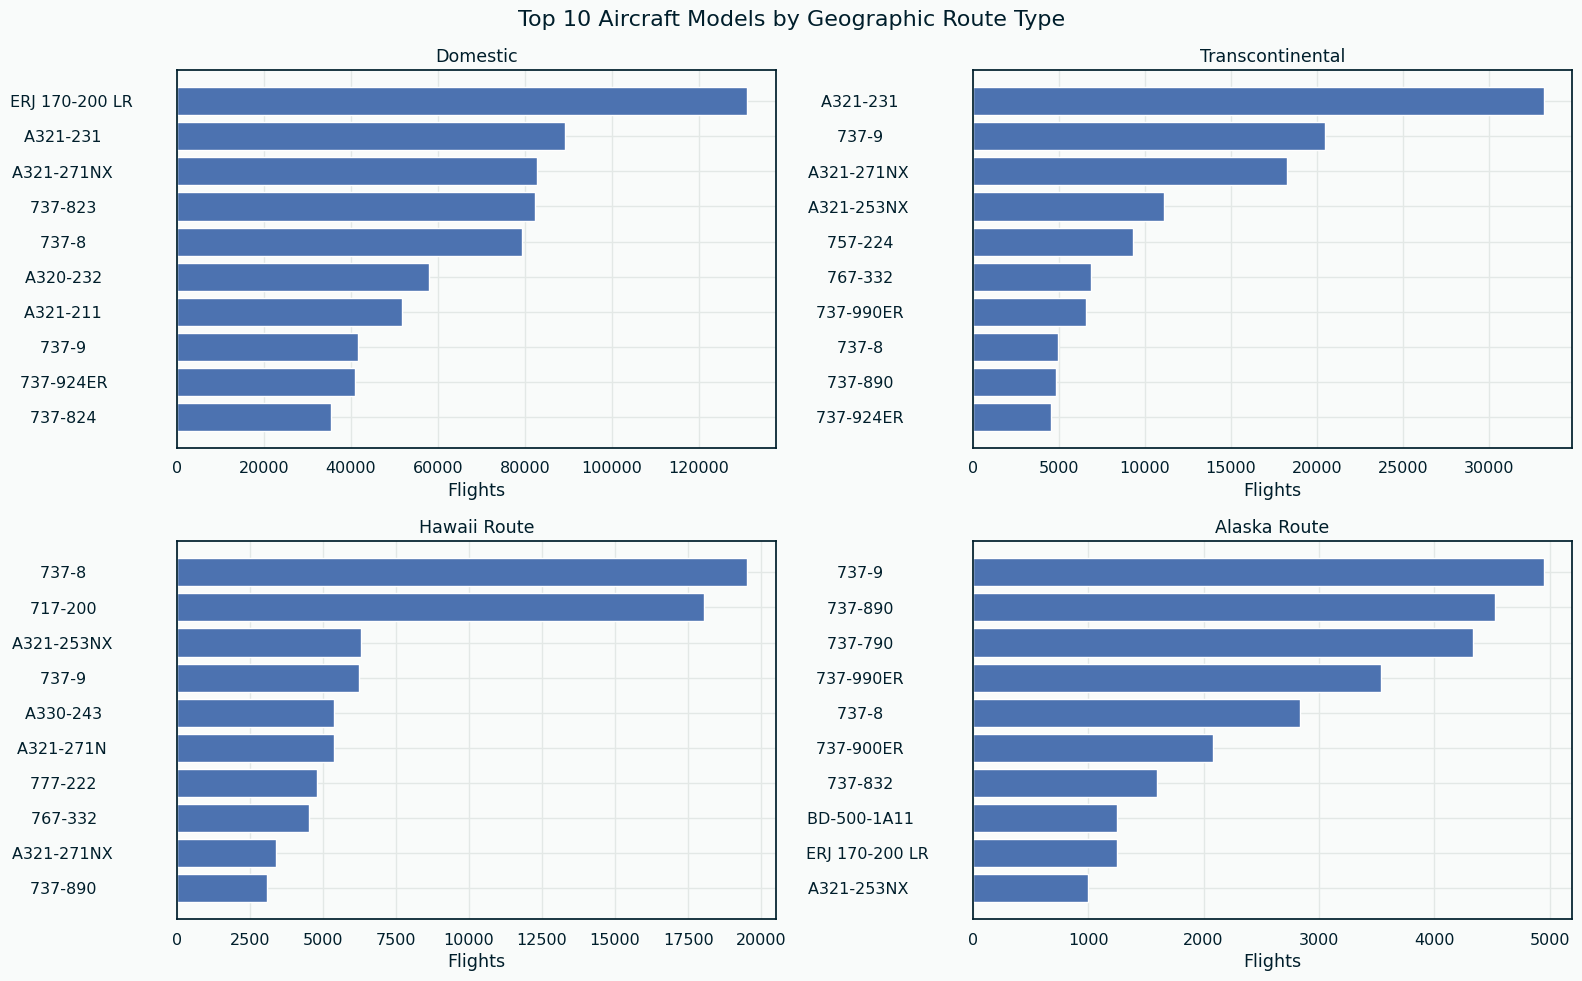

<Figure size 640x480 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

geo_types = df['GEO_TYPE'].unique()

for i, geo_type in enumerate(geo_types):
    data = df[df['GEO_TYPE'] == geo_type]['ACFT MODEL'].value_counts().head(10)
    axes[i].barh(data.index[::-1], data.values[::-1])
    axes[i].set_title(f'{geo_type}')
    axes[i].set_xlabel('Flights')

plt.suptitle('Top 10 Aircraft Models by Geographic Route Type', fontsize=16)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig('eda_10_Aircraft_Type_by_Geo_Route_Type.png', dpi=150, bbox_inches='tight')
plt.show()

Loading data...
  Shape: 1,532,364 rows x 84 columns
  Airports: 40  |  Airlines: 21  |  Aircraft models: 97
  Route types: {'Regional': 516805, 'Medium Haul': 444134, 'Long Haul': 425391, 'Short Hopper': 135864, 'Ultra Long Haul': 10170}
  Feature engineering complete.

Section 2: Airport-level Emissions...


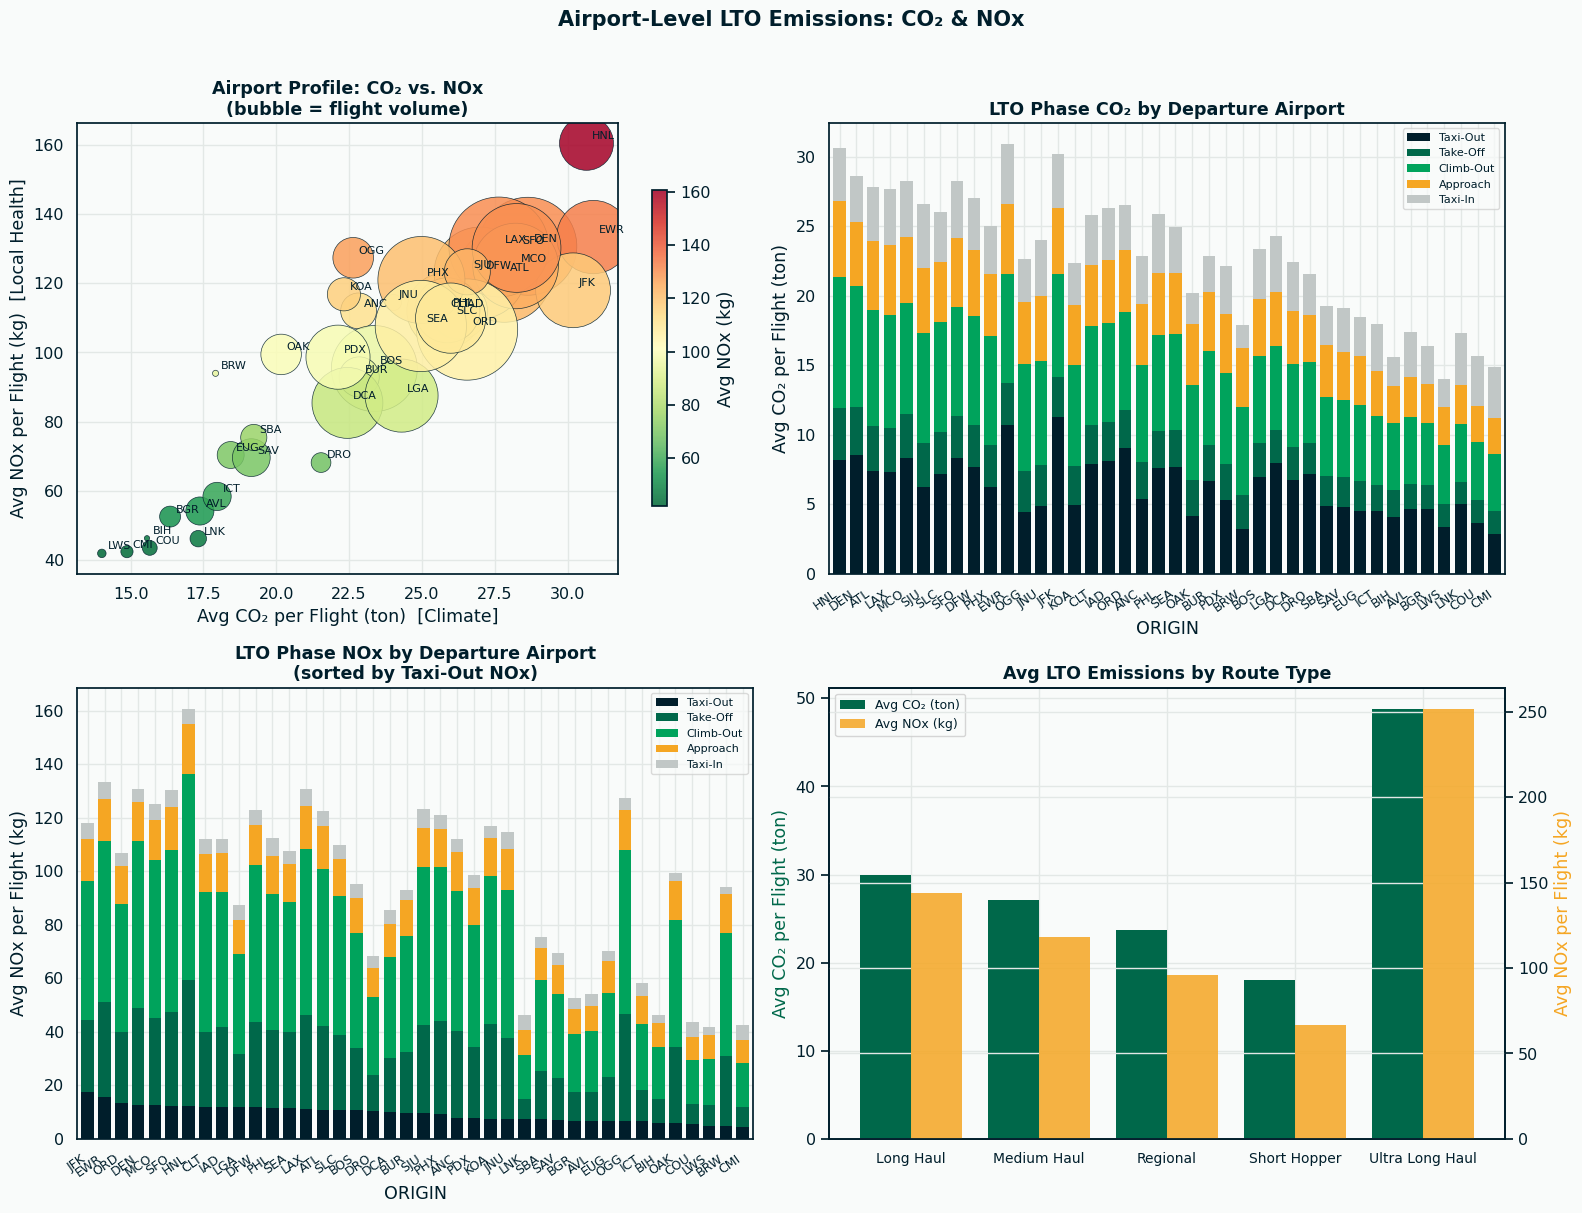

  -> eda_01_airport.png
Section 3: Airline-level Emissions...


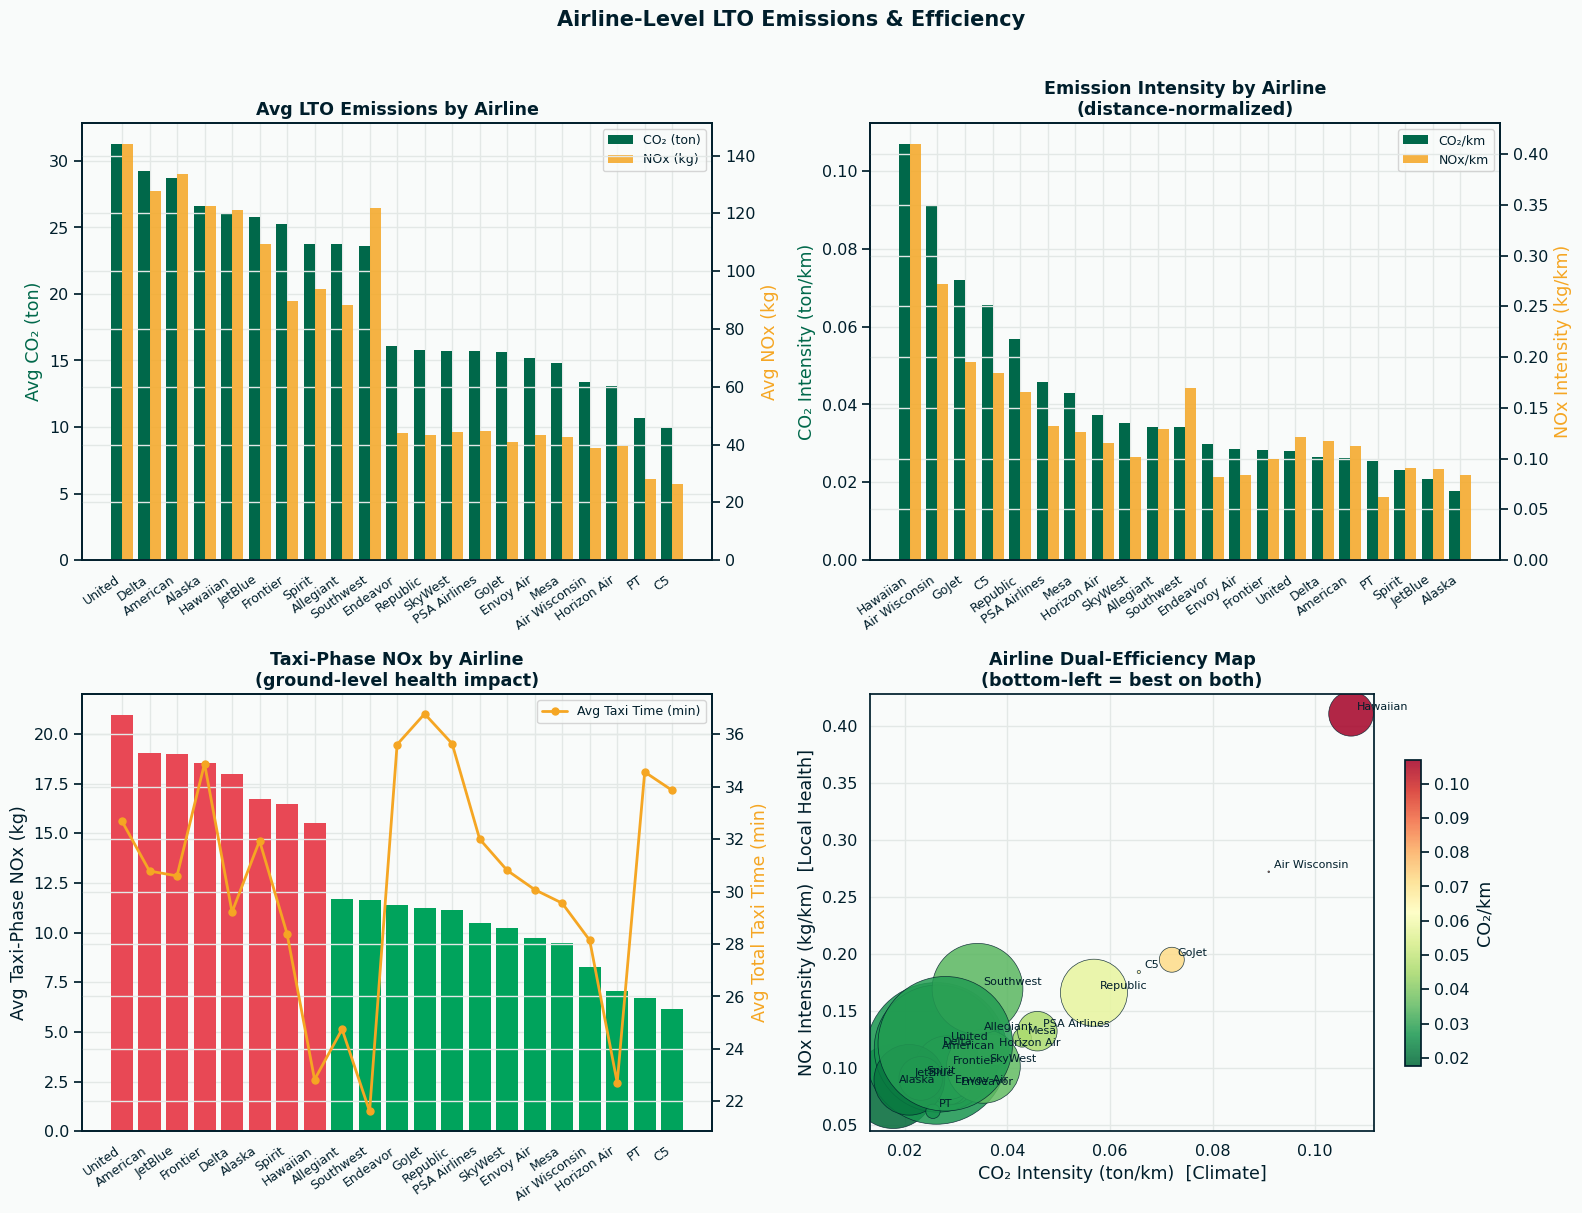

  -> eda_02_airline.png
Section 4: Weather & Operational Factors...


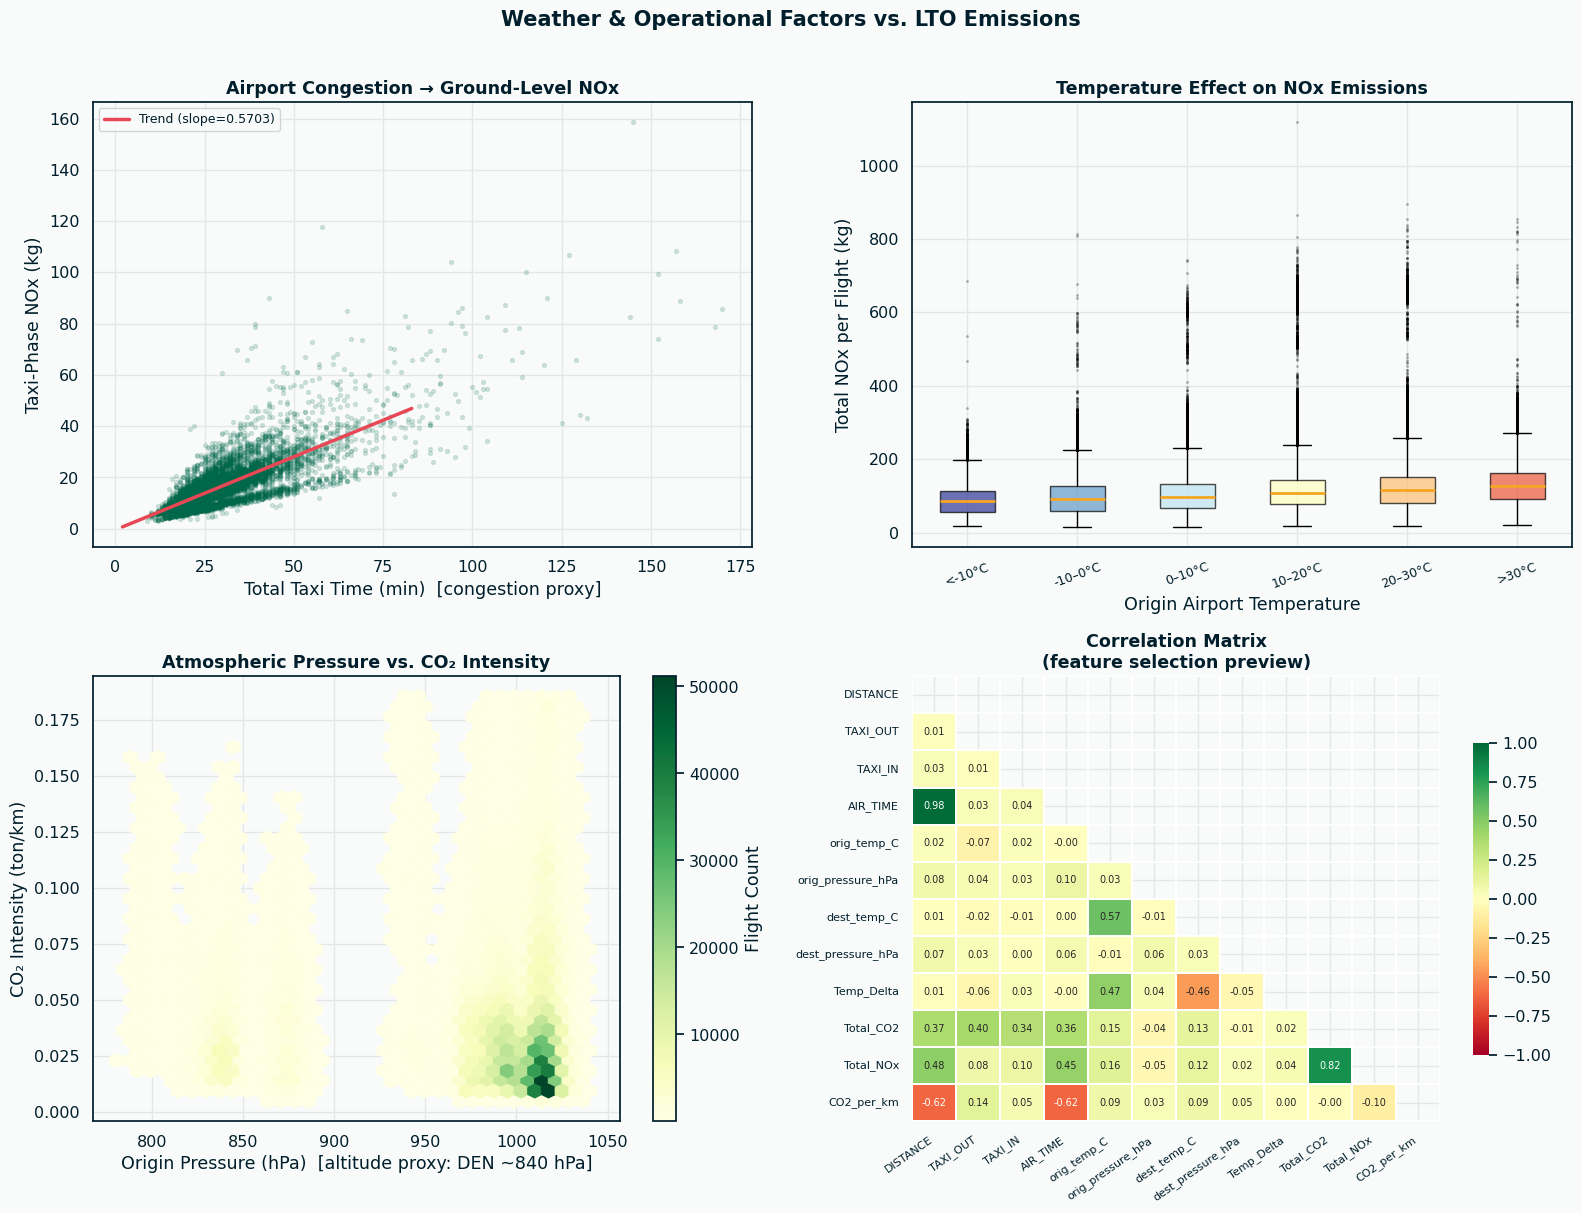

  -> eda_03_weather.png
Section 5: Aircraft & Fleet Composition...


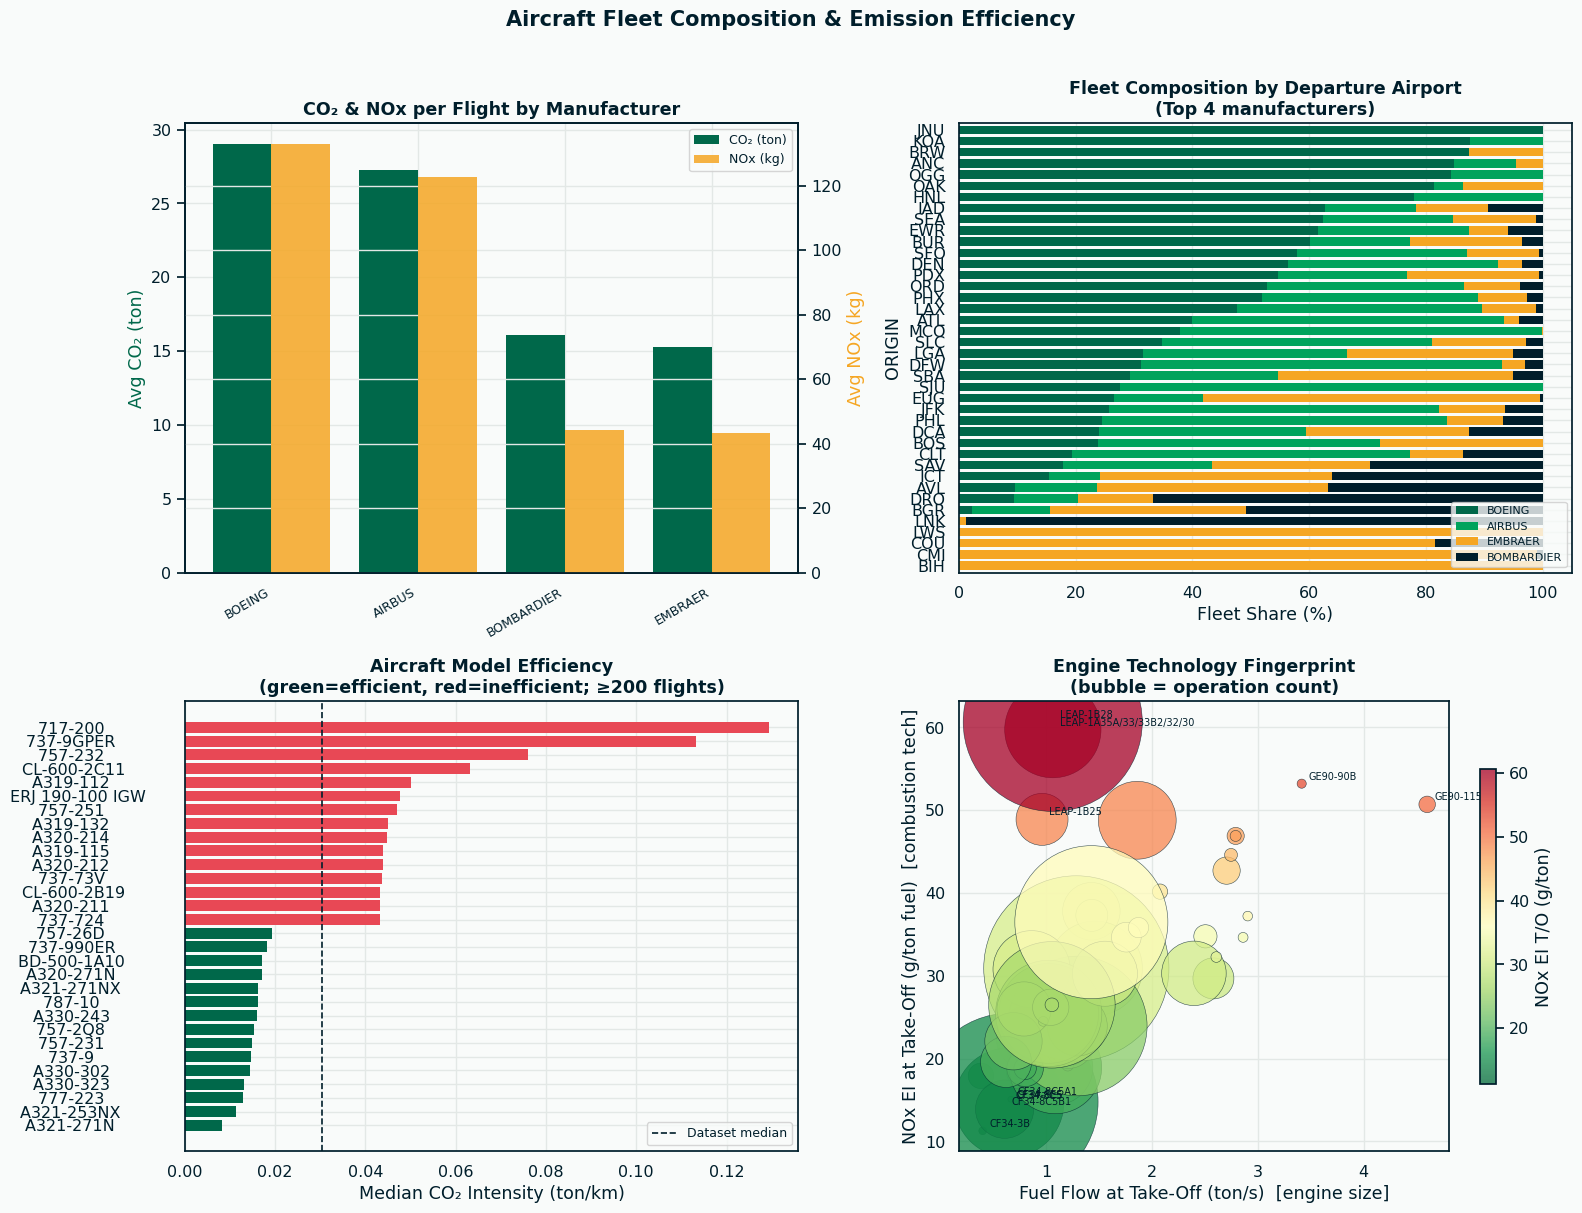

  -> eda_04_aircraft.png

SUMMARY
Flights:               1,532,364
Avg CO₂ per flight:      26.1015 ton
Avg NOx per flight:   114.094510 kg
Median CO₂/km:          0.028021 ton/km
Median NOx/km:        0.11353732 kg/km


In [ ]:
"""
EDA: Data-Driven Evaluation of Aircraft LTO Emissions Between Airports
CIVENG 160D Final Project

Sections:
  1. Setup & Feature Engineering
  2. Airport-level Emissions
  3. Airline-level Emissions
  4. Weather & Operational Factors
  5. Aircraft & Fleet Composition
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ─── Style ────────────────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#00684A",
    "secondary": "#001E2B",
    "accent":    "#00A35C",
    "warning":   "#F5A623",
    "danger":    "#E84855",
    "muted":     "#C1C7C6",
    "bg":        "#F9FBFA",
}
PHASE_COLORS = [
    PALETTE["secondary"], PALETTE["primary"],
    PALETTE["accent"], PALETTE["warning"], PALETTE["muted"]
]

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.facecolor": PALETTE["bg"],  "axes.facecolor":  PALETTE["bg"],
    "axes.edgecolor":   PALETTE["secondary"], "axes.labelcolor": PALETTE["secondary"],
    "xtick.color":      PALETTE["secondary"], "ytick.color":     PALETTE["secondary"],
    "text.color":       PALETTE["secondary"], "grid.color":      "#E3E8E6",
    "font.family":      "DejaVu Sans",
})

OUTPUT_DIR = "./"


# ─── 1. Setup & Feature Engineering ──────────────────────────────────────────
print("Loading data...")
df = pd.read_parquet("/content/40_2025_final.parquet")
print(f"  Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Phase columns
CO2_COLS = ["Taxi Out CO2", "Take Off CO2", "Climb Out CO2", "Approach CO2", "Taxi In CO2"]
NOX_COLS = ["Taxi Out NOx", "Take Off NOx", "Climb Out NOx", "Approach NOx", "Taxi In NOx"]
PHASE_LABELS = ["Taxi-Out", "Take-Off", "Climb-Out", "Approach", "Taxi-In"]

# Total LTO emissions per flight
df["Total_CO2"] = df[CO2_COLS].sum(axis=1)
df["Total_NOx"] = df[NOX_COLS].sum(axis=1)

# Distance-normalized intensity
df["CO2_per_km"] = df["Total_CO2"] / df["DISTANCE"].replace(0, np.nan)
df["NOx_per_km"] = df["Total_NOx"] / df["DISTANCE"].replace(0, np.nan)

# Taxi totals
df["Total_Taxi"] = df["TAXI_OUT"].fillna(0) + df["TAXI_IN"].fillna(0)
df["Taxi_CO2"]   = df["Taxi Out CO2"] + df["Taxi In CO2"]
df["Taxi_NOx"]   = df["Taxi Out NOx"] + df["Taxi In NOx"]

# Weather features
df["Temp_Bin"] = pd.cut(
    df["orig_temp_C"],
    bins=[-30, -10, 0, 10, 20, 30, 45],
    labels=["<-10°C", "-10–0°C", "0–10°C", "10–20°C", "20–30°C", ">30°C"]
)
df["Temp_Delta"] = df["orig_temp_C"] - df["dest_temp_C"]

# Carrier name mapping
CARRIER_NAMES = {
    "AA": "American",    "DL": "Delta",       "UA": "United",
    "WN": "Southwest",   "AS": "Alaska",      "B6": "JetBlue",
    "NK": "Spirit",      "F9": "Frontier",    "G4": "Allegiant",
    "HA": "Hawaiian",    "SY": "Sun Country",
    "9E": "Endeavor",    "OO": "SkyWest",     "YX": "Republic",
    "CP": "Compass",     "YV": "Mesa",
    "OH": "PSA Airlines","G7": "GoJet",
    "ZW": "Air Wisconsin","QX": "Horizon Air",
    "MQ": "Envoy Air",
}
df["Carrier_Name"] = df["OP_CARRIER"].map(CARRIER_NAMES).fillna(df["OP_CARRIER"])

print(f"  Airports: {df['ORIGIN'].nunique()}  |  Airlines: {df['OP_CARRIER'].nunique()}"
      f"  |  Aircraft models: {df['ACFT MODEL'].nunique()}")
print(f"  Route types: {df['ROUTE_TYPE'].value_counts().to_dict()}")
print("  Feature engineering complete.\n")


# ═══════════════════════════════════════════════════════════════════════════════
# 2. AIRPORT-LEVEL EMISSIONS
# ═══════════════════════════════════════════════════════════════════════════════
print("Section 2: Airport-level Emissions...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Airport-Level LTO Emissions: CO₂ & NOx",
             fontsize=15, fontweight="bold", color=PALETTE["secondary"], y=1.01)

# 2-1. CO2 vs NOx per flight by airport
ax = axes[0, 0]
ap_agg = (
    df.groupby("ORIGIN")
    .agg(avg_co2=("Total_CO2","mean"), avg_nox=("Total_NOx","mean"), count=("Total_CO2","size"))
    .reset_index()
)
sc = ax.scatter(
    ap_agg["avg_co2"], ap_agg["avg_nox"],
    s=ap_agg["count"] / 20, alpha=0.85,
    c=ap_agg["avg_nox"], cmap="RdYlGn_r",
    edgecolors=PALETTE["secondary"], linewidths=0.5
)
for _, row in ap_agg.iterrows():
    ax.annotate(row["ORIGIN"], (row["avg_co2"], row["avg_nox"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)
ax.set_xlabel("Avg CO₂ per Flight (ton)  [Climate]")
ax.set_ylabel("Avg NOx per Flight (kg)  [Local Health]")
ax.set_title("Airport Profile: CO₂ vs. NOx\n(bubble = flight volume)", fontweight="bold")
plt.colorbar(sc, ax=ax, label="Avg NOx (kg)", shrink=0.7)

# 2-2. LTO phase CO2 breakdown by airport
ax = axes[0, 1]
ap_phase_co2 = (
    df.groupby("ORIGIN")[CO2_COLS].mean()
    .rename(columns=dict(zip(CO2_COLS, PHASE_LABELS)))
    .sort_values("Climb-Out", ascending=False)
)
ap_phase_co2.plot(kind="bar", stacked=True, ax=ax,
                  color=PHASE_COLORS, edgecolor="none", width=0.75)
ax.set_ylabel("Avg CO₂ per Flight (ton)")
ax.set_title("LTO Phase CO₂ by Departure Airport", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

# 2-3. LTO phase NOx breakdown by airport
ax = axes[1, 0]
ap_phase_nox = (
    df.groupby("ORIGIN")[NOX_COLS].mean()
    .rename(columns=dict(zip(NOX_COLS, PHASE_LABELS)))
    .sort_values("Taxi-Out", ascending=False)
)
ap_phase_nox.plot(kind="bar", stacked=True, ax=ax,
                  color=PHASE_COLORS, edgecolor="none", width=0.75)
ax.set_ylabel("Avg NOx per Flight (kg)")
ax.set_title("LTO Phase NOx by Departure Airport\n(sorted by Taxi-Out NOx)", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

# 2-4. Emissions by route type
ax = axes[1, 1]
route_agg = (
    df.groupby("ROUTE_TYPE")[["Total_CO2", "Total_NOx"]].mean().reset_index()
)
x = np.arange(len(route_agg))
ax_r = ax.twinx()
ax.bar(x - 0.2, route_agg["Total_CO2"], width=0.4,
       color=PALETTE["primary"], label="Avg CO₂ (ton)", edgecolor="none")
ax_r.bar(x + 0.2, route_agg["Total_NOx"], width=0.4,
         color=PALETTE["warning"], label="Avg NOx (kg)", edgecolor="none", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(route_agg["ROUTE_TYPE"], fontsize=10)
ax.set_ylabel("Avg CO₂ per Flight (ton)", color=PALETTE["primary"])
ax_r.set_ylabel("Avg NOx per Flight (kg)", color=PALETTE["warning"])
ax.set_title("Avg LTO Emissions by Route Type", fontweight="bold")
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_01_airport.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> eda_01_airport.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 3. AIRLINE-LEVEL EMISSIONS
# ═══════════════════════════════════════════════════════════════════════════════
print("Section 3: Airline-level Emissions...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Airline-Level LTO Emissions & Efficiency",
             fontsize=15, fontweight="bold", color=PALETTE["secondary"], y=1.01)

# 3-1. Avg CO2 & NOx per flight by airline
ax = axes[0, 0]
ca_agg = (
    df.groupby("Carrier_Name")
    .agg(avg_co2=("Total_CO2","mean"), avg_nox=("Total_NOx","mean"))
    .sort_values("avg_co2", ascending=False)
    .reset_index()
)
x = np.arange(len(ca_agg))
ax_r = ax.twinx()
ax.bar(x - 0.2, ca_agg["avg_co2"], width=0.4,
       color=PALETTE["primary"], label="CO₂ (ton)", edgecolor="none")
ax_r.bar(x + 0.2, ca_agg["avg_nox"], width=0.4,
         color=PALETTE["warning"], label="NOx (kg)", edgecolor="none", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ca_agg["Carrier_Name"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Avg CO₂ (ton)", color=PALETTE["primary"])
ax_r.set_ylabel("Avg NOx (kg)", color=PALETTE["warning"])
ax.set_title("Avg LTO Emissions by Airline", fontweight="bold")
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9)

# 3-2. CO2 & NOx intensity (ton/km)
ax = axes[0, 1]
intensity = (
    df.groupby("Carrier_Name")
    .agg(co2_km=("CO2_per_km","median"), nox_km=("NOx_per_km","median"))
    .sort_values("co2_km", ascending=False)
    .reset_index()
)
x2 = np.arange(len(intensity))
ax_r2 = ax.twinx()
ax.bar(x2 - 0.2, intensity["co2_km"], width=0.4,
       color=PALETTE["primary"], label="CO₂/km", edgecolor="none")
ax_r2.bar(x2 + 0.2, intensity["nox_km"], width=0.4,
          color=PALETTE["warning"], label="NOx/km", edgecolor="none", alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(intensity["Carrier_Name"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("CO₂ Intensity (ton/km)", color=PALETTE["primary"])
ax_r2.set_ylabel("NOx Intensity (kg/km)", color=PALETTE["warning"])
ax.set_title("Emission Intensity by Airline\n(distance-normalized)", fontweight="bold")
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r2.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9)

# 3-3. Taxi NOx by airline
ax = axes[1, 0]
taxi_agg = (
    df.groupby("Carrier_Name")
    .agg(taxi_nox=("Taxi_NOx","mean"), taxi_time=("Total_Taxi","mean"))
    .sort_values("taxi_nox", ascending=False)
    .reset_index()
)
colors_taxi = [PALETTE["danger"] if v > taxi_agg["taxi_nox"].median() * 1.2
               else PALETTE["accent"] for v in taxi_agg["taxi_nox"]]
ax.bar(range(len(taxi_agg)), taxi_agg["taxi_nox"], color=colors_taxi, edgecolor="none")
ax_r3 = ax.twinx()
ax_r3.plot(range(len(taxi_agg)), taxi_agg["taxi_time"],
           color=PALETTE["warning"], linewidth=2, marker="o", ms=5, label="Avg Taxi Time (min)")
ax.set_xticks(range(len(taxi_agg)))
ax.set_xticklabels(taxi_agg["Carrier_Name"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Avg Taxi-Phase NOx (kg)")
ax_r3.set_ylabel("Avg Total Taxi Time (min)", color=PALETTE["warning"])
ax.set_title("Taxi-Phase NOx by Airline\n(ground-level health impact)", fontweight="bold")
ax_r3.legend(fontsize=9, loc="upper right")

# 3-4. Dual-efficiency map
ax = axes[1, 1]
eff = (
    df.groupby("Carrier_Name")
    .agg(co2_km=("CO2_per_km","median"), nox_km=("NOx_per_km","median"),
         count=("Total_CO2","size"))
    .reset_index()
)
sc2 = ax.scatter(
    eff["co2_km"], eff["nox_km"],
    s=eff["count"] / 30, alpha=0.85,
    c=eff["co2_km"], cmap="RdYlGn_r",
    edgecolors=PALETTE["secondary"], linewidths=0.5
)
for _, row in eff.iterrows():
    ax.annotate(row["Carrier_Name"], (row["co2_km"], row["nox_km"]),
                textcoords="offset points", xytext=(4, 3), fontsize=8)
ax.set_xlabel("CO₂ Intensity (ton/km)  [Climate]")
ax.set_ylabel("NOx Intensity (kg/km)  [Local Health]")
ax.set_title("Airline Dual-Efficiency Map\n(bottom-left = best on both)", fontweight="bold")
plt.colorbar(sc2, ax=ax, label="CO₂/km", shrink=0.7)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_02_airline.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> eda_02_airline.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 4. WEATHER & OPERATIONAL FACTORS
# ═══════════════════════════════════════════════════════════════════════════════
print("Section 4: Weather & Operational Factors...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Weather & Operational Factors vs. LTO Emissions",
             fontsize=15, fontweight="bold", color=PALETTE["secondary"], y=1.01)

# 4-1. Taxi time vs. Taxi NOx
ax = axes[0, 0]
sample = df.sample(min(8000, len(df)), random_state=42)
ax.scatter(sample["Total_Taxi"], sample["Taxi_NOx"],
           alpha=0.15, s=8, color=PALETTE["primary"])
valid = df[["Total_Taxi", "Taxi_NOx"]].dropna()
z = np.polyfit(valid["Total_Taxi"], valid["Taxi_NOx"], 1)
xline = np.linspace(df["Total_Taxi"].min(), df["Total_Taxi"].quantile(0.99), 100)
ax.plot(xline, np.poly1d(z)(xline), color=PALETTE["danger"], linewidth=2.5,
        label=f"Trend (slope={z[0]:.4f})")
ax.set_xlabel("Total Taxi Time (min)  [congestion proxy]")
ax.set_ylabel("Taxi-Phase NOx (kg)")
ax.set_title("Airport Congestion → Ground-Level NOx", fontweight="bold")
ax.legend(fontsize=9)

# 4-2. Temperature bin vs. Total NOx
ax = axes[0, 1]
temp_box = [df[df["Temp_Bin"] == b]["Total_NOx"].dropna().values
            for b in df["Temp_Bin"].cat.categories]
bp = ax.boxplot(temp_box, labels=list(df["Temp_Bin"].cat.categories),
                patch_artist=True,
                medianprops=dict(color=PALETTE["warning"], linewidth=2),
                flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, col in zip(bp["boxes"],
                      [plt.cm.RdYlBu_r(i/len(bp["boxes"])) for i in range(len(bp["boxes"]))]):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xlabel("Origin Airport Temperature")
ax.set_ylabel("Total NOx per Flight (kg)")
ax.set_title("Temperature Effect on NOx Emissions", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, fontsize=9)

# 4-3. Atmospheric pressure vs. CO2 intensity
ax = axes[1, 0]
vp = df.dropna(subset=["orig_pressure_hPa", "CO2_per_km"])
vp = vp[vp["CO2_per_km"] < vp["CO2_per_km"].quantile(0.99)]
h = ax.hexbin(vp["orig_pressure_hPa"], vp["CO2_per_km"],
              gridsize=35, cmap="YlGn", mincnt=5)
plt.colorbar(h, ax=ax, label="Flight Count")
ax.set_xlabel("Origin Pressure (hPa)  [altitude proxy: DEN ~840 hPa]")
ax.set_ylabel("CO₂ Intensity (ton/km)")
ax.set_title("Atmospheric Pressure vs. CO₂ Intensity", fontweight="bold")

# 4-4. Correlation heatmap
ax = axes[1, 1]
feat_cols = [
    "DISTANCE", "TAXI_OUT", "TAXI_IN", "AIR_TIME",
    "orig_temp_C", "orig_pressure_hPa",
    "dest_temp_C", "dest_pressure_hPa",
    "Temp_Delta", "Total_CO2", "Total_NOx", "CO2_per_km"
]
corr = df[feat_cols].corr()
sns.heatmap(
    corr, ax=ax, mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True, fmt=".2f", annot_kws={"size": 7},
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.3, cbar_kws={"shrink": 0.7}
)
ax.set_title("Correlation Matrix\n(feature selection preview)", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_03_weather.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> eda_03_weather.png")


# ═══════════════════════════════════════════════════════════════════════════════
# 5. AIRCRAFT & FLEET COMPOSITION
# ═══════════════════════════════════════════════════════════════════════════════
print("Section 5: Aircraft & Fleet Composition...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Aircraft Fleet Composition & Emission Efficiency",
             fontsize=15, fontweight="bold", color=PALETTE["secondary"], y=1.01)

# 5-1. CO2 & NOx by aircraft manufacturer
ax = axes[0, 0]
mfr_agg = (
    df.groupby("ACFT MFR CLEAN")
    .agg(avg_co2=("Total_CO2","mean"), avg_nox=("Total_NOx","mean"), count=("Total_CO2","size"))
    .query("count >= 100")
    .sort_values("avg_co2", ascending=False)
    .reset_index()
)
x = np.arange(len(mfr_agg))
ax_r = ax.twinx()
ax.bar(x - 0.2, mfr_agg["avg_co2"], width=0.4,
       color=PALETTE["primary"], label="CO₂ (ton)", edgecolor="none")
ax_r.bar(x + 0.2, mfr_agg["avg_nox"], width=0.4,
         color=PALETTE["warning"], label="NOx (kg)", edgecolor="none", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(mfr_agg["ACFT MFR CLEAN"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Avg CO₂ (ton)", color=PALETTE["primary"])
ax_r.set_ylabel("Avg NOx (kg)", color=PALETTE["warning"])
ax.set_title("CO₂ & NOx per Flight by Manufacturer", fontweight="bold")
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9)

# 5-2. Fleet mix by airport
ax = axes[0, 1]
fleet_mix = df.groupby(["ORIGIN", "ACFT MFR CLEAN"]).size().reset_index(name="cnt")
fleet_pct = fleet_mix.pivot(index="ORIGIN", columns="ACFT MFR CLEAN", values="cnt").fillna(0)
fleet_pct = fleet_pct.div(fleet_pct.sum(axis=1), axis=0) * 100
top_mfrs = fleet_pct.sum().sort_values(ascending=False).head(4).index.tolist()
fleet_pct[top_mfrs].sort_values(top_mfrs[0]).plot(
    kind="barh", stacked=True, ax=ax,
    color=[PALETTE["primary"], PALETTE["accent"], PALETTE["warning"], PALETTE["secondary"]],
    edgecolor="none", width=0.75
)
ax.set_xlabel("Fleet Share (%)")
ax.set_title("Fleet Composition by Departure Airport\n(Top 4 manufacturers)", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)

# 5-3. CO2 per km efficiency ranking by aircraft model
ax = axes[1, 0]
model_eff = (
    df.groupby("ACFT MODEL")
    .agg(co2_km=("CO2_per_km","median"), count=("CO2_per_km","size"))
    .query("count >= 200")
    .sort_values("co2_km")
    .reset_index()
)
n = min(15, len(model_eff))
combined = pd.concat([model_eff.head(n), model_eff.tail(n)]).drop_duplicates()
median_val = model_eff["co2_km"].median()
colors_eff = [PALETTE["primary"] if v <= median_val else PALETTE["danger"]
              for v in combined["co2_km"]]
ax.barh(combined["ACFT MODEL"], combined["co2_km"], color=colors_eff, edgecolor="none")
ax.axvline(median_val, color=PALETTE["secondary"], linestyle="--", linewidth=1.2,
           label="Dataset median")
ax.set_xlabel("Median CO₂ Intensity (ton/km)")
ax.set_title("Aircraft Model Efficiency\n(green=efficient, red=inefficient; ≥200 flights)",
             fontweight="bold")
ax.legend(fontsize=9)

# 5-4. NOx EI vs. Fuel Flow
ax = axes[1, 1]
eng_agg = (
    df.groupby("Engine Identification")
    .agg(
        nox_ei   =("NOx EI T/O (g/kg)",     "mean"),
        fuel_flow=("Fuel Flow T/O (kg/sec)", "mean"),
        count    =("Total_CO2",              "size")
    )
    .query("count >= 100")
    .reset_index()
)
sc3 = ax.scatter(
    eng_agg["fuel_flow"], eng_agg["nox_ei"],
    s=eng_agg["count"] / 10, alpha=0.75,
    c=eng_agg["nox_ei"], cmap="RdYlGn_r",
    edgecolors=PALETTE["secondary"], linewidths=0.4
)
ax.set_xlabel("Fuel Flow at Take-Off (ton/s)  [engine size]")
ax.set_ylabel("NOx EI at Take-Off (g/ton fuel)  [combustion tech]")
ax.set_title("Engine Technology Fingerprint\n(bubble = operation count)", fontweight="bold")
plt.colorbar(sc3, ax=ax, label="NOx EI T/O (g/ton)", shrink=0.7)

top5_eng    = eng_agg.nlargest(5,  "nox_ei")
bottom5_eng = eng_agg.nsmallest(5, "nox_ei")
for _, row in pd.concat([top5_eng, bottom5_eng]).iterrows():
    ax.annotate(
        row["Engine Identification"],
        (row["fuel_flow"], row["nox_ei"]),
        textcoords="offset points", xytext=(5, 3),
        fontsize=7, color=PALETTE["secondary"]
    )

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_04_aircraft.png", dpi=150, bbox_inches="tight")
plt.show()
print("  -> eda_04_aircraft.png")


# ─── Summary ──────────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Flights:              {len(df):>10,}")
print(f"Avg CO₂ per flight:   {df['Total_CO2'].mean():>10.4f} ton")
print(f"Avg NOx per flight:   {df['Total_NOx'].mean():>10.6f} kg")
print(f"Median CO₂/km:        {df['CO2_per_km'].median():>10.6f} ton/km")
print(f"Median NOx/km:        {df['NOx_per_km'].median():>10.8f} kg/km")

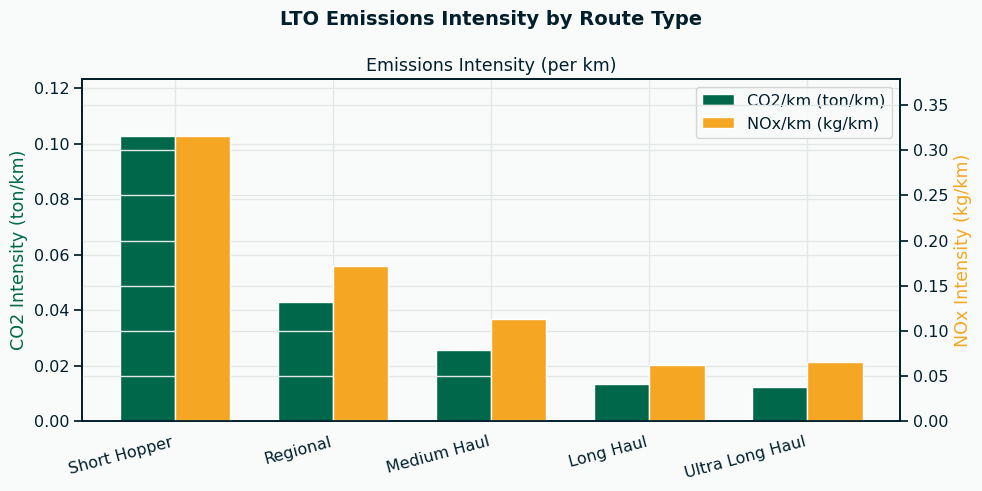

Saved: eda_route_efficiency.png


In [ ]:
route_efficiency = df.groupby("ROUTE_TYPE").agg(
    avg_CO2_per_km = ("CO2_per_km", "median"),
    avg_NOx_per_km = ("NOx_per_km", "median"),
).reindex(["Short Hopper", "Regional", "Medium Haul", "Long Haul", "Ultra Long Haul"])

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("LTO Emissions Intensity by Route Type",
             fontsize=14, fontweight="bold", color=PALETTE["secondary"])

x = np.arange(len(route_efficiency))
width = 0.35
ax_r = ax.twinx()

ax.bar(x - width/2, route_efficiency["avg_CO2_per_km"], width, label="CO2/km (ton/km)", color=PALETTE["primary"])
ax_r.bar(x + width/2, route_efficiency["avg_NOx_per_km"], width, label="NOx/km (kg/km)", color=PALETTE["warning"])

ax.set_xticks(x)
ax.set_xticklabels(route_efficiency.index, rotation=15, ha="right")
ax.set_ylabel("CO2 Intensity (ton/km)", color=PALETTE["primary"])
ax_r.set_ylabel("NOx Intensity (kg/km)", color=PALETTE["warning"])
ax.set_title("Emissions Intensity (per km)")

# y축 0부터 같은 비율로 맞추기
co2_max = route_efficiency["avg_CO2_per_km"].max() * 1.2
nox_max = route_efficiency["avg_NOx_per_km"].max() * 1.2
ax.set_ylim(0, co2_max)
ax_r.set_ylim(0, nox_max)

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_route_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_route_efficiency.png")

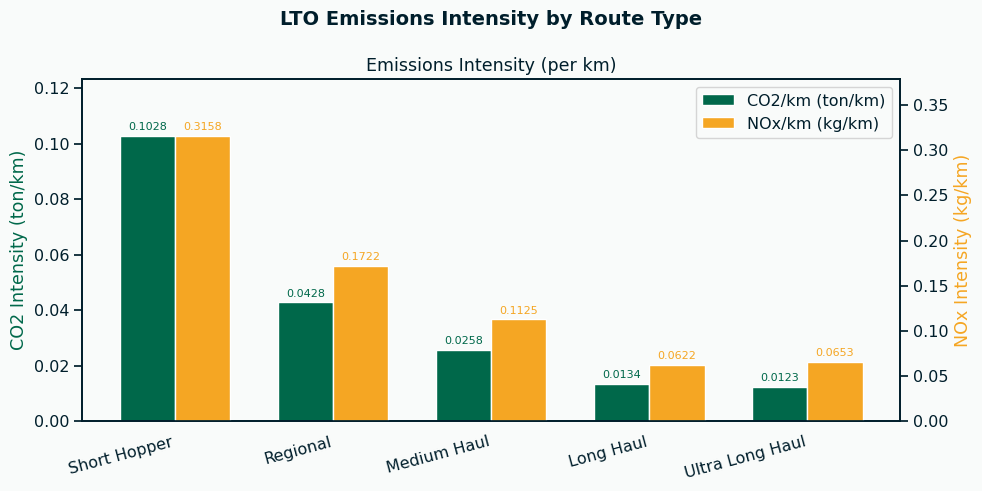

Saved: eda_route_efficiency.png


In [ ]:
route_efficiency = df.groupby("ROUTE_TYPE").agg(
    avg_CO2_per_km = ("CO2_per_km", "median"),
    avg_NOx_per_km = ("NOx_per_km", "median"),
).reindex(["Short Hopper", "Regional", "Medium Haul", "Long Haul", "Ultra Long Haul"])

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("LTO Emissions Intensity by Route Type",
             fontsize=14, fontweight="bold", color=PALETTE["secondary"])

x = np.arange(len(route_efficiency))
width = 0.35
ax_r = ax.twinx()

bars1 = ax.bar(x - width/2, route_efficiency["avg_CO2_per_km"], width, label="CO2/km (ton/km)", color=PALETTE["primary"])
bars2 = ax_r.bar(x + width/2, route_efficiency["avg_NOx_per_km"], width, label="NOx/km (kg/km)", color=PALETTE["warning"])

# 숫자 표시
for i, v in enumerate(route_efficiency["avg_CO2_per_km"]):
    ax.text(i - width/2, v + route_efficiency["avg_CO2_per_km"].max() * 0.02,
            f"{v:.4f}", ha="center", fontsize=8, color=PALETTE["primary"])
for i, v in enumerate(route_efficiency["avg_NOx_per_km"]):
    ax_r.text(i + width/2, v + route_efficiency["avg_NOx_per_km"].max() * 0.02,
              f"{v:.4f}", ha="center", fontsize=8, color=PALETTE["warning"])

ax.set_xticks(x)
ax.set_xticklabels(route_efficiency.index, rotation=15, ha="right")
ax.set_ylabel("CO2 Intensity (ton/km)", color=PALETTE["primary"])
ax_r.set_ylabel("NOx Intensity (kg/km)", color=PALETTE["warning"])
ax.set_title("Emissions Intensity (per km)")

co2_max = route_efficiency["avg_CO2_per_km"].max() * 1.2
nox_max = route_efficiency["avg_NOx_per_km"].max() * 1.2
ax.set_ylim(0, co2_max)
ax_r.set_ylim(0, nox_max)

# grid 제거
ax.grid(False)
ax_r.grid(False)

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_r.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_route_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_route_efficiency.png")

In [ ]:
mfr_efficiency = df.groupby("ACFT MFR CLEAN").agg(
    avg_CO2_per_km = ("CO2_per_km", "median"),
    avg_NOx_per_km = ("NOx_per_km", "median"),
    flight_count   = ("Total_CO2",  "size"),
).query("flight_count >= 1000").sort_values("avg_CO2_per_km")

print(mfr_efficiency[["avg_CO2_per_km", "avg_NOx_per_km", "flight_count"]].round(4))

                avg_CO2_per_km  avg_NOx_per_km  flight_count
ACFT MFR CLEAN                                              
AIRBUS                  0.0252          0.1081        598839
BOEING                  0.0274          0.1199        679445
BOMBARDIER              0.0384          0.1072         71174
EMBRAER                 0.0397          0.1168        182878


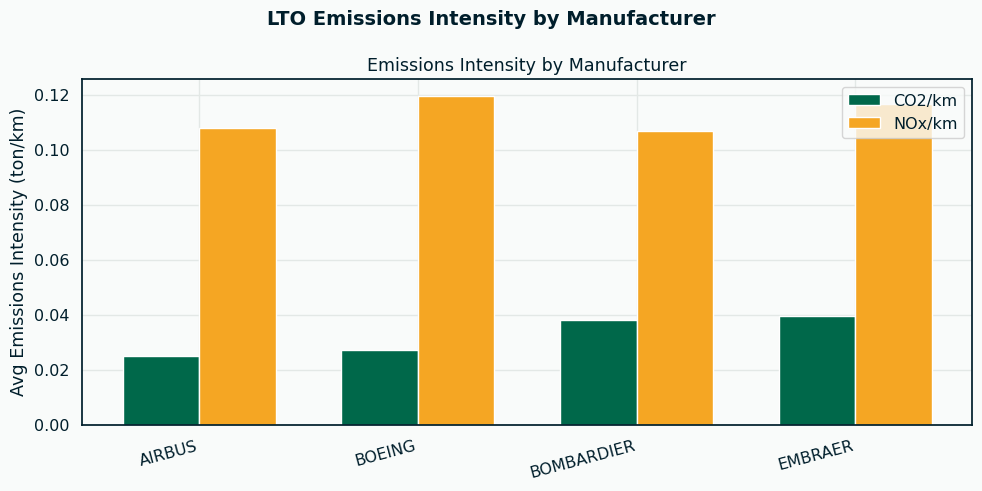

Saved: eda_mfr_efficiency.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("LTO Emissions Intensity by Manufacturer",
             fontsize=14, fontweight="bold", color=PALETTE["secondary"])

x = np.arange(len(mfr_efficiency))
width = 0.35

ax.bar(x - width/2, mfr_efficiency["avg_CO2_per_km"], width, label="CO2/km", color=PALETTE["primary"])
ax.bar(x + width/2, mfr_efficiency["avg_NOx_per_km"], width, label="NOx/km", color=PALETTE["warning"])
ax.set_xticks(x)
ax.set_xticklabels(mfr_efficiency.index, rotation=15, ha="right")
ax.set_ylabel("Avg Emissions Intensity (ton/km)")
ax.set_title("Emissions Intensity by Manufacturer")
ax.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}eda_mfr_efficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: eda_mfr_efficiency.png")

In [ ]:
import shutil
import glob
from google.colab import drive

# 드라이브 마운트
drive.mount('/content/drive')

# 저장할 폴더 경로 (없으면 자동 생성)
dest_folder = 'https://drive.google.com/drive/u/0/folders/1pswOp1BDdQdR7V6MScQYMgtH-cQBX-NH'
import os
os.makedirs(dest_folder, exist_ok=True)

# 현재 폴더의 eda_*.png 전부 복사
files = glob.glob('/content/eda_*.png')
for f in sorted(files):
    shutil.copy(f, dest_folder)
    print(f"✅ {os.path.basename(f)}")

print(f"\n완료! 총 {len(files)}개 → {dest_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ eda_00_aircraft_routes.png
✅ eda_01_Top_Aircraft_Manufacturers.png
✅ eda_01_airport.png
✅ eda_02_airline.png
✅ eda_03_weather.png
✅ eda_04_aircraft.png
✅ eda_05_Distance_Distribution_by_route_Type.png
✅ eda_06_Taxi_Out_vs_Taxi_In_Time_Distribution.png
✅ eda_07_Taxi_InOut_by_OD_Airport.png
✅ eda_08_Aircraft_Type_by_Airline.png
✅ eda_08_Aircraft_Type_by_Geo_Route_Type.png
✅ eda_09_Top_Aircraft_by_Route_Type.png
✅ eda_10_Aircraft_Type_by_Geo_Route_Type.png

완료! 총 13개 → https://drive.google.com/drive/u/0/folders/1pswOp1BDdQdR7V6MScQYMgtH-cQBX-NH


In [ ]:
import shutil, glob, os
from google.colab import drive

drive.mount('/content/drive')

# 폴더 ID로 직접 경로 지정
folder_id = '1pswOp1BDdQdR7V6MScQYMgtH-cQBX-NH'
dest = f'/content/drive/MyDrive/폴더명'  # 실제 폴더명으로 바꿔줘

# 또는 shortcuts 방식
# dest = f'/content/drive/Shareddrives/...'

os.makedirs(dest, exist_ok=True)

files = glob.glob('/content/eda_*.png')
for f in sorted(files):
    shutil.copy(f, dest)
    print(f"✅ {os.path.basename(f)}")

print(f"\n완료! {len(files)}개 복사됨")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ eda_00_aircraft_routes.png
✅ eda_01_Top_Aircraft_Manufacturers.png
✅ eda_01_airport.png
✅ eda_02_airline.png
✅ eda_03_weather.png
✅ eda_04_aircraft.png
✅ eda_05_Distance_Distribution_by_route_Type.png
✅ eda_06_Taxi_Out_vs_Taxi_In_Time_Distribution.png
✅ eda_07_Taxi_InOut_by_OD_Airport.png
✅ eda_08_Aircraft_Type_by_Airline.png
✅ eda_08_Aircraft_Type_by_Geo_Route_Type.png
✅ eda_09_Top_Aircraft_by_Route_Type.png
✅ eda_10_Aircraft_Type_by_Geo_Route_Type.png

완료! 13개 복사됨
